In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import pandas as pd
import pickle as pkl

import scipy.signal as ss
import scipy.io as sio
from scipy.signal import butter, lfilter, hilbert
from scipy import signal
from scipy.signal import freqz
from scipy.signal import butter, lfilter, freqz, find_peaks
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d
from scipy.signal import hilbert

def get_envelope(signal):
    return np.abs(hilbert(signal))

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y




import sys
sys.path.append('/home/diogo/miniforge3/envs/core_neuron/lib/python')
import neuron

# Visualization

In [567]:
with open('../data/validation_CoreNeuron/validation_CoreNeuron_0_data.pkl', 'rb') as file:
    info = pkl.load(file)

data = info['simData'].copy()
info.pop('simData', None)
cellType = info['simConfig']['cellTypeByIndex']
spkt = np.array(data['spkt'])
spkid = np.array(data['spkid'])
time = np.linspace(0, info['simConfig']['duration'], int(info['simConfig']['duration']/info['simConfig']['dt'])+1)

pyr = [0,799]
sst = [800, 849]
pv = [850, 919]
vip = [920, 999]

In [568]:
data['V_soma'].keys()

dict_keys(['cell_0', 'cell_1', 'cell_2', 'cell_3'])

In [569]:
data.keys()

dict_keys(['spkt', 'spkid', 'V_soma', 't', 'popRates', 'avgRate'])

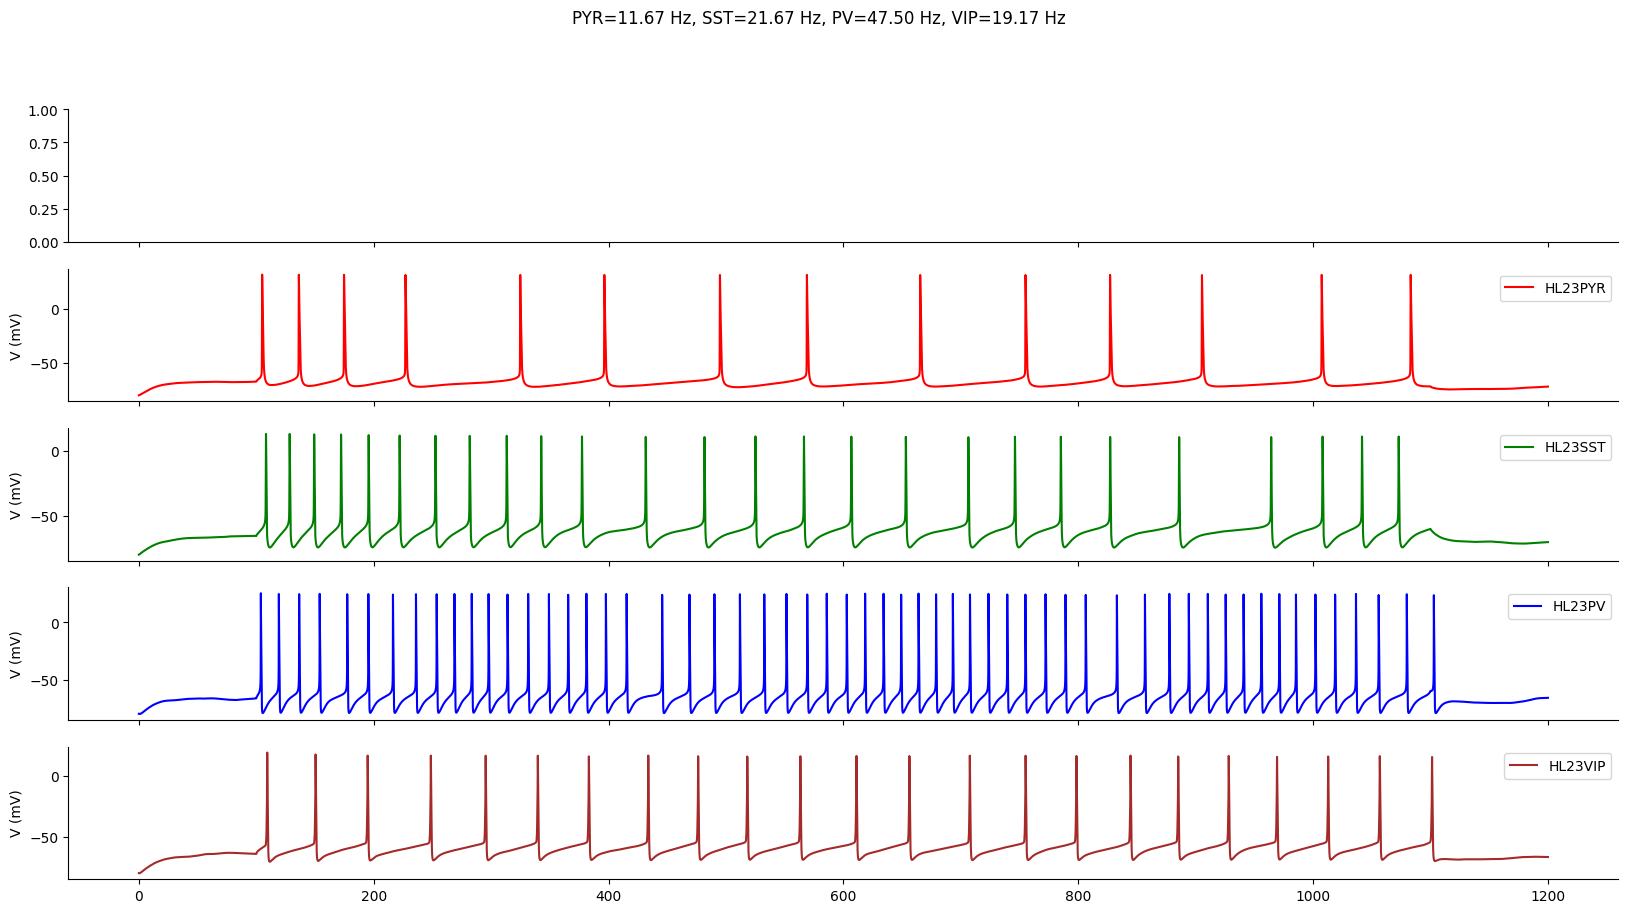

In [570]:
cells = ['cell_0', 'cell_1', 'cell_2', 'cell_3']

fig, axes = plt.subplots(len(cells)+1, 1, figsize = (20,10), sharex = True)
colors = {'HL23PYR': 'red', 'HL23SST':'green', 'HL23VIP':'brown', 'HL23PV':'blue'}

# axes[0].plot(time, data['IClamp']['HL23PYR'])
# axes[0].set_ylabel('Iclamp (nA)')

for id, cell in enumerate(cells):
    num = cell.split('_')[-1]
    axes[id+1].plot(time, data['V_soma'][cell], c = colors[cellType[num]], label = cellType[num])
    axes[id+1].set_ylabel('V (mV)')
    axes[id+1].legend()

plt.suptitle(f"PYR={data['popRates']['HL23PYR']:.2f} Hz, SST={data['popRates']['HL23SST']:.2f} Hz, PV={data['popRates']['HL23PV']:.2f} Hz, VIP={data['popRates']['HL23VIP']:.2f} Hz")
sns.despine()

cell_0
cell_80


TypeError: 'Dict' object is not callable

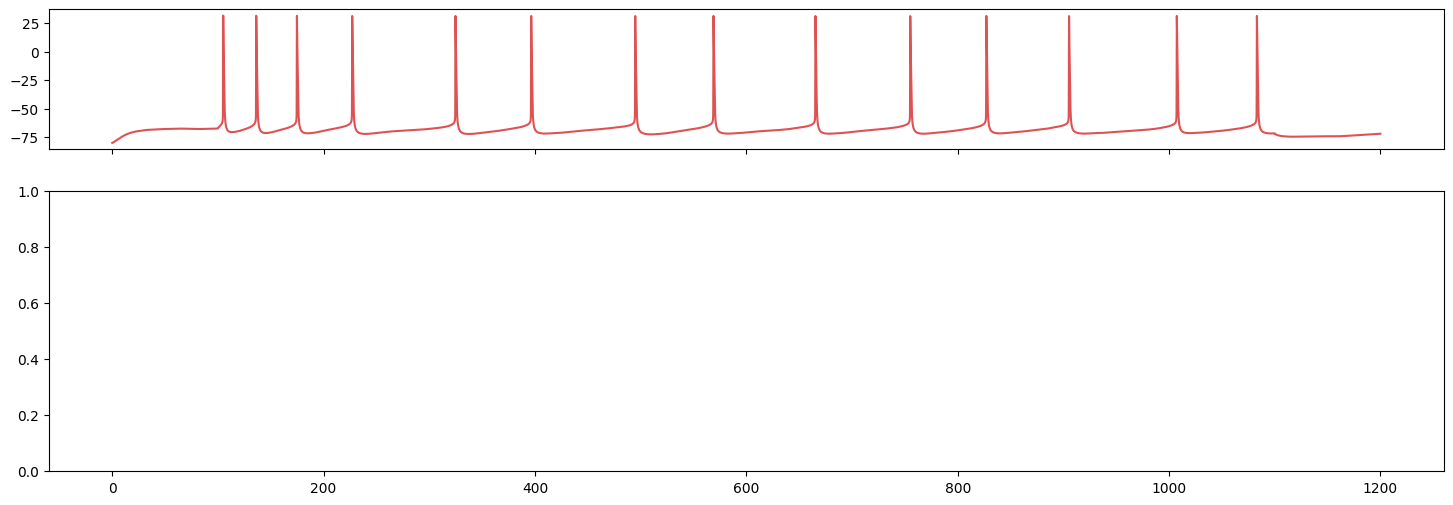

In [571]:
record_cells = ['cell_0', 'cell_80', 'cell_85', 'cell_92']

# Population GID ranges
populations = {
    'PYR': (0, 79),
    'SST': (80, 84),
    'PV':  (85, 91),
    'VIP': (92, 99)
}

# Colors
pop_colors = {
    'PYR': 'tab:red',
    'SST': 'tab:orange',
    'PV':  'tab:green',
    'VIP': 'tab:blue'
}

def get_population(gid):
    for pop, (start, end) in populations.items():
        if start <= gid <= end:
            return pop
    return None


fig, axes = plt.subplots(
    2, 1,
    figsize=(18, 6),
    sharex=True,
    gridspec_kw={'height_ratios': [1, 2]}
)


# --------------------------------------------------
# Voltage traces
# --------------------------------------------------

for cell in record_cells:

    gid = int(cell.split('_')[-1])
    pop = get_population(gid)
    print(cell)
    axes[0].plot(
        time,
        data['V_soma'][cell],
        color=pop_colors[pop],
        alpha=0.8
    )

axes[0].set_ylabel('V (mV)')


# --------------------------------------------------
# Raster plot
# --------------------------------------------------

for gid in np.unique(spkid):

    pop = get_population(int(gid))

    mask = spkid == gid

    axes[1].scatter(
        spkt[mask],
        spkid[mask],
        s=1.0,
        color=pop_colors[pop],
        rasterized=True
    )

axes[1].set_xlim(0, 1200)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('GID')


# --------------------------------------------------
# Population legend
# --------------------------------------------------

suffix = 'HL23'

legend_handles = []

# for pop in populations:

#     key = suffix + pop

#     cv = data['CV'][key]['CV']
#     kuramoto = data['Kuramoto'][key]['Rmean']
#     frequency = data['popRates'][key]

#     label = (
#         f'{pop}  '
#         f'(CV = {cv:.2f}, '
#         f'R = {kuramoto:.2f}, '
#         f'f = {frequency:.2f} Hz)'
#     )

#     legend_handles.append(
#         Line2D(
#             [0], [0],
#             color=pop_colors[pop],
#             lw=2.5,
#             label=label
#         )
#     )

axes[0].legend(
    handles=legend_handles,
    loc='upper right',
    frameon=False
)

sns.despine()

plt.tight_layout()
plt.show()

# Validation Neuron/CoreNeuron

In [700]:
import os
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Paths
# ============================================================

BASE_DIR = '../data'

single_runs = {
    'Old NEURON': 'validation_OldNeuron',
    'New NEURON': 'validation_Neuron',
    'CoreNEURON CPU': 'validation_CoreNeuron',
    'CoreNEURON GPU': 'validation_CoreNeuron_GPU',
}

network_runs = {
    'NEURON 1 Core': '1Core_Neuron',
    'NEURON 2 Core': '2Core_Neuron',
    'NEURON 10 Core': '10Core_Neuron',
    'NEURON 20 Core': '20Core_Neuron',
    'CoreNEURON 1 Core': '1Core_CoreNeuron',
    'CoreNEURON 2 Core': '2Core_CoreNeuron',
    'CoreNEURON 10 Core': '10Core_CoreNeuron',
    'CoreNEURON 20 Core': '20Core_CoreNeuron',
    'CoreNEURON GPU': 'validationNetwork_CoreNeuron_GPU'
}

# Voltage traces that you recorded
single_voltage_cells = {
    'HL23PYR': 0,
    'HL23SST': 1,
    'HL23PV': 2,
    'HL23VIP': 3,
}

network_voltage_cells = {
    'HL23PYR': 0,
    'HL23SST': 80,
    'HL23PV': 85,
    'HL23VIP': 92,
}

populations = [
    'HL23PYR',
    'HL23SST',
    'HL23PV',
    'HL23VIP'
]

In [ ]:
def load_netpyne_run(run_name, base_dir=BASE_DIR):

    filename = os.path.join(
        base_dir,
        run_name,
        f'{run_name}_0_data.pkl'
    )

    with open(filename, 'rb') as file:
        info = pkl.load(file)

    data = info['simData'].copy()

    sim_config = info['simConfig']

    duration = float(sim_config['duration'])
    dt = float(sim_config['dt'])

    spkt = np.asarray(data['spkt'], dtype=float)
    spkid = np.asarray(data['spkid'], dtype=int)

    # --------------------------------------------------------
    # cellTypeByIndex can sometimes have str keys after saving
    # --------------------------------------------------------

    raw_cell_type = sim_config['cellTypeByIndex']

    cell_type = {
        int(gid): pop
        for gid, pop in raw_cell_type.items()
    }

    return {
        'name': run_name,
        'info': info,
        'data': data,
        'config': sim_config,
        'duration': duration,
        'dt': dt,
        'spkt': spkt,
        'spkid': spkid,
        'cellType': cell_type,
    }

single = {
    label: load_netpyne_run(run)
    for label, run in single_runs.items()
}

network = {
    label: load_netpyne_run(run)
    for label, run in network_runs.items()
}

In [701]:
single = {
    label: load_netpyne_run(run)
    for label, run in single_runs.items()
}

network = {
    label: load_netpyne_run(run)
    for label, run in network_runs.items()
}

In [639]:
for label, run in single.items():
    print(
        label,
        'duration =', run['duration'],
        'n spikes =', len(run['spkt'])
    )

print()

for label, run in network.items():
    print(
        label,
        'duration =', run['duration'],
        'n spikes =', len(run['spkt'])
    )

Old NEURON duration = 1200.0 n spikes = 85
New NEURON duration = 1200.0 n spikes = 120
CoreNEURON CPU duration = 1200.0 n spikes = 120
CoreNEURON GPU duration = 1200.0 n spikes = 85

NEURON 1 Core duration = 5200.0 n spikes = 5018
NEURON 2 Core duration = 5200.0 n spikes = 5016
NEURON 10 Core duration = 5200.0 n spikes = 5030
NEURON 20 Core duration = 5200.0 n spikes = 5012
CoreNEURON 1 Core duration = 5200.0 n spikes = 5018
CoreNEURON 2 Core duration = 5200.0 n spikes = 5016
CoreNEURON 10 Core duration = 5200.0 n spikes = 5030
CoreNEURON 20 Core duration = 5200.0 n spikes = 5012


In [576]:
def get_population_gids(run, population):

    return np.array([
        gid
        for gid, pop in run['cellType'].items()
        if pop == population
    ], dtype=int)

In [577]:
for pop in populations:
    gids = get_population_gids(network['Old NEURON'], pop)
    print(pop, len(gids), gids[:10])

HL23PYR 80 [0 1 2 3 4 5 6 7 8 9]
HL23SST 5 [80 81 82 83 84]
HL23PV 7 [85 86 87 88 89 90 91]
HL23VIP 8 [92 93 94 95 96 97 98 99]


In [578]:
def get_voltage(run, gid):

    key = f'cell_{gid}'

    voltage = np.asarray(
        run['data']['V_soma'][key],
        dtype=float
    )

    # Prefer saved t if available
    if 't' in run['data']:
        t = np.asarray(run['data']['t'], dtype=float)

        # Occasionally t and trace differ by one sample
        n = min(len(t), len(voltage))

        return t[:n], voltage[:n]

    # Otherwise derive it
    dt = float(
        run['config'].get(
            'recordStep',
            run['dt']
        )
    )

    t = np.arange(len(voltage)) * dt

    return t, voltage

In [579]:
teste = [['Old NEURON', single['Old NEURON']], ['New NEURON', single['New NEURON']], ['CoreNEURON CPU', single['CoreNEURON CPU']], ['CoreNEURON GPU', single['CoreNEURON GPU']]]


HL23PYR New NEURON max |dV| = 103.0825267718783 mV
HL23PYR CoreNEURON CPU max |dV| = 103.08252677192209 mV
HL23PYR CoreNEURON GPU max |dV| = 1.3083010230729997e-09 mV
HL23SST New NEURON max |dV| = 86.03032760811001 mV
HL23SST CoreNEURON CPU max |dV| = 86.03032760810981 mV
HL23SST CoreNEURON GPU max |dV| = 4.663647246161418e-10 mV
HL23PV New NEURON max |dV| = 103.9288553690386 mV
HL23PV CoreNEURON CPU max |dV| = 103.92885536885555 mV
HL23PV CoreNEURON GPU max |dV| = 1.3492854833430101e-08 mV
HL23VIP New NEURON max |dV| = 86.59118111422934 mV
HL23VIP CoreNEURON CPU max |dV| = 86.59118111422535 mV
HL23VIP CoreNEURON GPU max |dV| = 1.8807586599223214e-09 mV


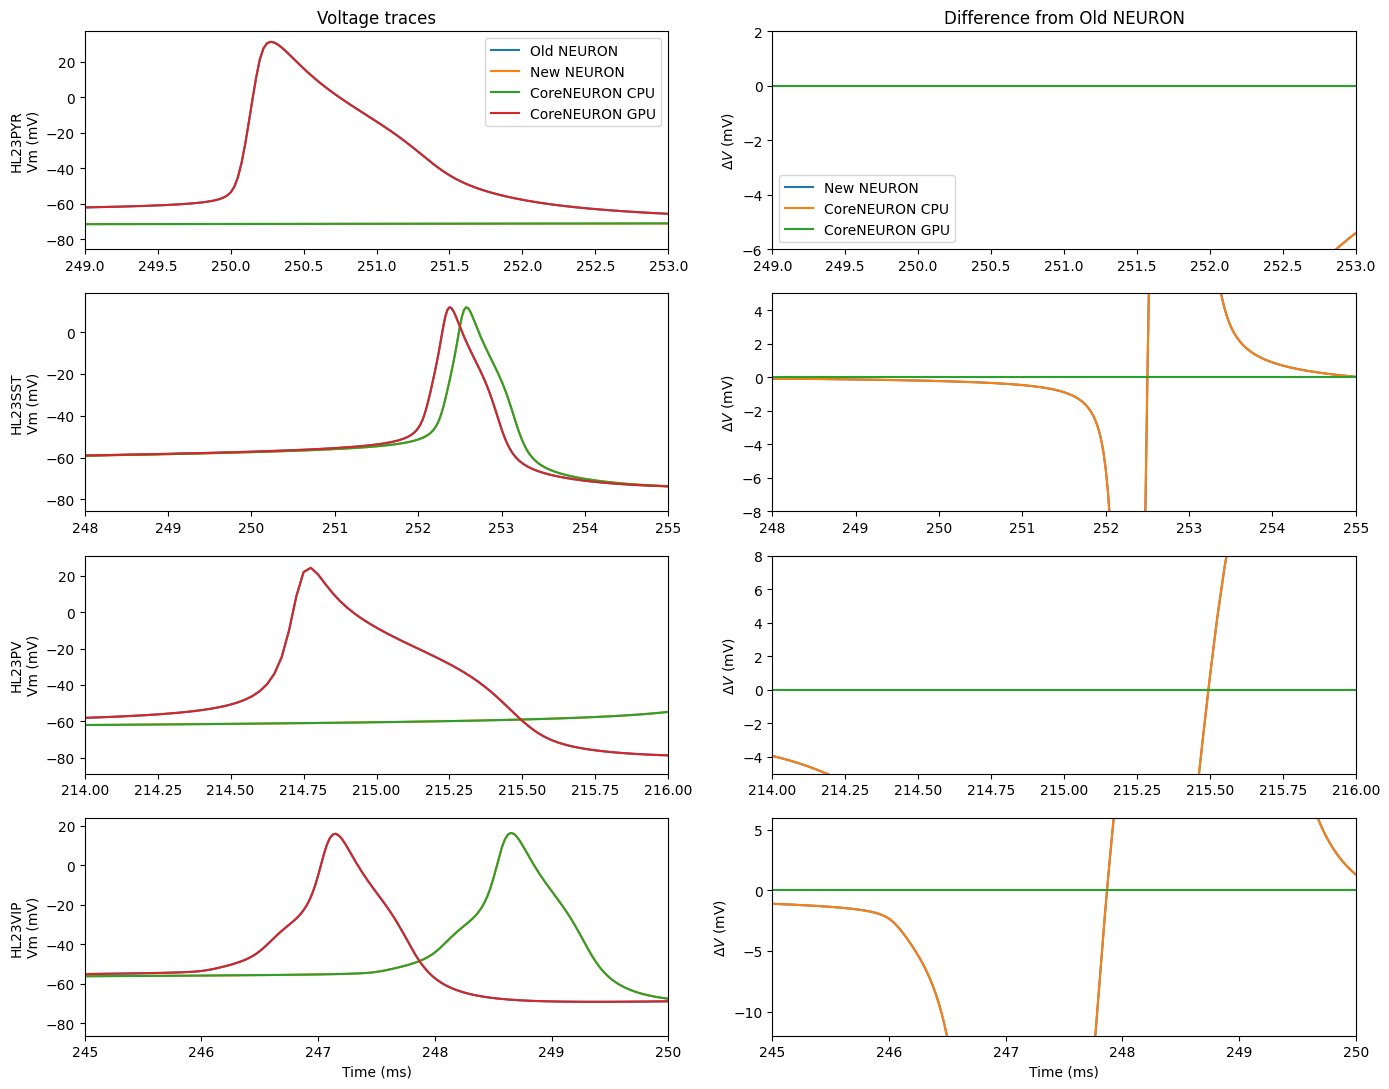

In [580]:
reference_label = 'Old NEURON'

# ------------------------------------------------------------
# Time vector
# ------------------------------------------------------------

duration = single[reference_label]['duration']
dt = single[reference_label]['dt']

t = np.linspace(
    0,
    duration,
    int(duration / dt) + 1
)

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(populations),
    2,
    figsize=(14, 11),
    #sharex=True
)

for i, pop in enumerate(populations):

    gid = single_voltage_cells[pop]
    cell = f'cell_{gid}'

    # --------------------------------------------------------
    # Reference
    # --------------------------------------------------------

    v_ref = np.asarray(
        single[reference_label]['data']['V_soma'][cell]
    )

    # --------------------------------------------------------
    # Voltage traces
    # --------------------------------------------------------

    for label, run in teste:#single.items():

        v = np.asarray(
            run['data']['V_soma'][cell]
        )

        assert len(v) == len(t), (
            f'{label}, {pop}: '
            f'voltage has {len(v)} points, '
            f'time has {len(t)} points'
        )

        axes[i, 0].plot(
            t,
            v,
            label=label
        )

    # --------------------------------------------------------
    # Difference from Old NEURON
    # --------------------------------------------------------

    for label, run in single.items():

        if label == reference_label:
            continue

        v = np.asarray(
            run['data']['V_soma'][cell]
        )

        dv = v - v_ref

        axes[i, 1].plot(
            t,
            dv,
            label=label
        )

        print(
            pop,
            label,
            'max |dV| =',
            np.max(np.abs(dv)),
            'mV'
        )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    axes[i, 0].set_ylabel(
        f'{pop}\nVm (mV)'
    )

    axes[i, 1].set_ylabel(
        r'$\Delta V$ (mV)'
    )

axes[0, 0].set_title(
    'Voltage traces'
)

axes[0, 1].set_title(
    'Difference from Old NEURON'
)

axes[0, 0].legend()
axes[0, 1].legend()

axes[-1, 0].set_xlabel('Time (ms)')
axes[-1, 1].set_xlabel('Time (ms)')

axes[0,0].set_xlim(249,253)
axes[1,0].set_xlim(248,255)
axes[2,0].set_xlim(214,216)
axes[3,0].set_xlim(245,250)

axes[0,1].set_xlim(249,253)
axes[1,1].set_xlim(248,255)
axes[2,1].set_xlim(214,216)
axes[3,1].set_xlim(245,250)


axes[0,1].set_ylim(-6,2)
axes[1,1].set_ylim(-8,5)
axes[2,1].set_ylim(-5,8)
axes[3,1].set_ylim(-12,6)

plt.tight_layout()
plt.show()

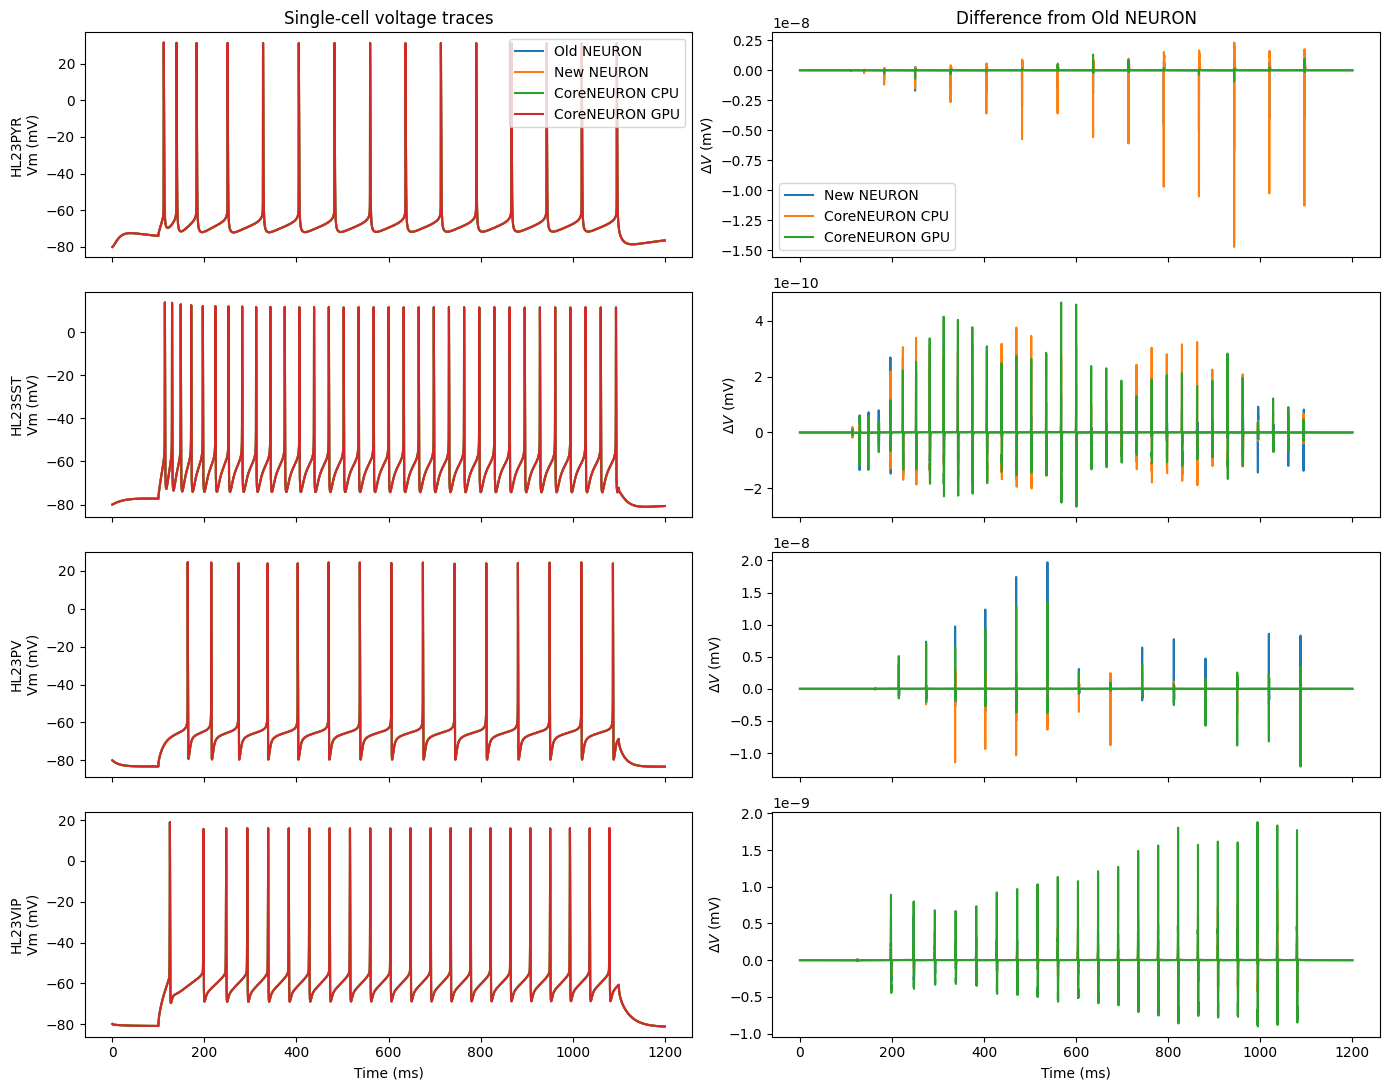

In [ ]:
reference_label = 'Old NEURON'

fig, axes = plt.subplots(
    4,
    2,
    figsize=(14, 11),
    sharex='col'
)

single_error_rows = []

for i, pop in enumerate(populations):

    gid = single_voltage_cells[pop]
    cell = f'cell_{gid}'

    # Reference
    v_ref = np.asarray(
        single[reference_label]['data']['V_soma'][cell],
        dtype=float
    )

    dt = single[reference_label]['dt']

    t = np.arange(
        len(v_ref)
    ) * dt

    # --------------------------------------------------------
    # Voltage traces
    # --------------------------------------------------------

    for label, run in single.items():

        v = np.asarray(
            run['data']['V_soma'][cell],
            dtype=float
        )

        assert v.shape == v_ref.shape

        axes[i, 0].plot(
            t,
            v,
            label=label
        )

    # --------------------------------------------------------
    # Voltage differences
    # --------------------------------------------------------

    for label, run in single.items():

        if label == reference_label:
            continue

        v = np.asarray(
            run['data']['V_soma'][cell],
            dtype=float
        )

        dv = v - v_ref

        axes[i, 1].plot(
            t,
            dv,
            label=label
        )

        single_error_rows.append({
            'Population': pop,
            'Backend': label,
            'Max |dV| (mV)': np.max(np.abs(dv)),
            'RMSE (mV)': np.sqrt(np.mean(dv**2)),
            'MAE (mV)': np.mean(np.abs(dv)),
        })

    axes[i, 0].set_ylabel(
        f'{pop}\nVm (mV)'
    )

    axes[i, 1].set_ylabel(
        r'$\Delta V$ (mV)'
    )

axes[0, 0].set_title(
    'Single-cell voltage traces'
)

axes[0, 1].set_title(
    'Difference from Old NEURON'
)

axes[0, 0].legend()
axes[0, 1].legend()

axes[-1, 0].set_xlabel('Time (ms)')
axes[-1, 1].set_xlabel('Time (ms)')

plt.tight_layout()
plt.show()

In [ ]:
def get_spike_times_from_voltage(
    v,
    dt,
    threshold=0.0
):
    """
    Detect upward threshold crossings.
    """

    v = np.asarray(v)

    crossings = np.where(
        (v[:-1] < threshold) &
        (v[1:] >= threshold)
    )[0]

    # Linear interpolation for sub-dt spike time
    spike_times = []

    for i in crossings:

        v0 = v[i]
        v1 = v[i + 1]

        frac = (
            threshold - v0
        ) / (
            v1 - v0
        )

        spike_time = (
            i + frac
        ) * dt

        spike_times.append(
            spike_time
        )

    return np.asarray(spike_times)

In [ ]:
def get_spike_times_from_voltage(
    v,
    dt,
    threshold=0.0
):
    """
    Detect upward threshold crossings.
    """

    v = np.asarray(v)

    crossings = np.where(
        (v[:-1] < threshold) &
        (v[1:] >= threshold)
    )[0]

    # Linear interpolation for sub-dt spike time
    spike_times = []

    for i in crossings:

        v0 = v[i]
        v1 = v[i + 1]

        frac = (
            threshold - v0
        ) / (
            v1 - v0
        )

        spike_time = (
            i + frac
        ) * dt

        spike_times.append(
            spike_time
        )

    return np.asarray(spike_times)

In [ ]:
spike_time_rows = []

for pop in populations:

    gid = single_voltage_cells[pop]
    cell = f'cell_{gid}'

    dt = single['Old NEURON']['dt']

    # Reference
    v_ref = np.asarray(
        single['Old NEURON']['data']['V_soma'][cell]
    )

    spikes_ref = get_spike_times_from_voltage(
        v_ref,
        dt,
        threshold=0.0
    )

    for backend in [
        'CoreNEURON CPU',
        'CoreNEURON GPU'
    ]:

        v = np.asarray(
            single[backend]['data']['V_soma'][cell]
        )

        spikes = get_spike_times_from_voltage(
            v,
            dt,
            threshold=0.0
        )

        n = min(
            len(spikes_ref),
            len(spikes)
        )

        for k in range(n):

            spike_time_rows.append({
                'Population': pop,
                'Backend': backend,
                'Spike number': k + 1,
                'Old NEURON time (ms)': spikes_ref[k],
                'Backend time (ms)': spikes[k],
                'Delta t (ms)': (
                    spikes[k] -
                    spikes_ref[k]
                )
            })

spike_time_df = pd.DataFrame(
    spike_time_rows
)

spike_time_df

,Population,Backend,Spike number,Old NEURON time (ms),Backend time (ms),Delta t (ms)
0,HL23PYR,CoreNEURON CPU,1,111.610133,111.610133,1.421085e-14
1,HL23PYR,CoreNEURON CPU,2,139.335122,139.335122,4.547474e-13
2,HL23PYR,CoreNEURON CPU,3,182.917195,182.917195,2.273737e-12
3,HL23PYR,CoreNEURON CPU,4,250.152097,250.152097,3.041123e-12
4,HL23PYR,CoreNEURON CPU,5,327.203211,327.203211,5.286438e-12
...,...,...,...,...,...,...
165,HL23VIP,CoreNEURON GPU,18,907.785495,907.785495,-7.275958e-12
166,HL23VIP,CoreNEURON GPU,19,950.863779,950.863779,-7.275958e-12
167,HL23VIP,CoreNEURON GPU,20,993.881085,993.881085,-8.640200e-12
168,HL23VIP,CoreNEURON GPU,21,1036.842828,1036.842828,-8.185452e-12


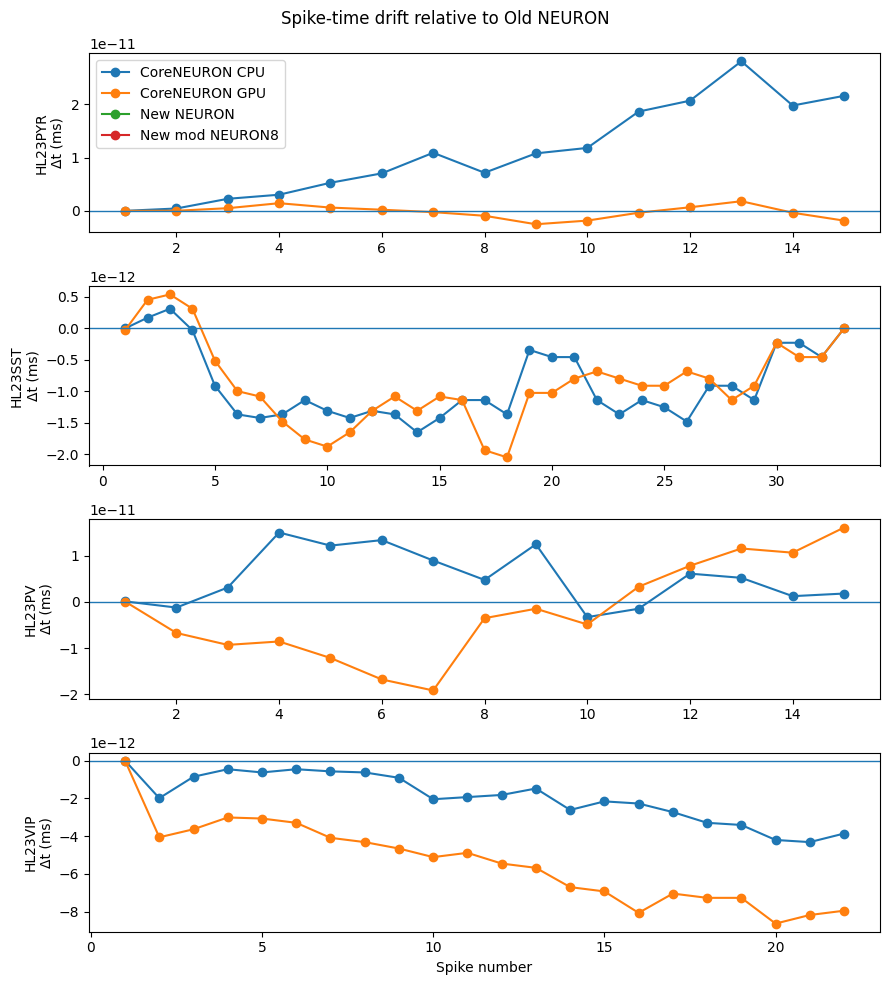

In [ ]:
fig, axes = plt.subplots(
    4,
    1,
    figsize=(9, 10),
    sharex=False
)

for ax, pop in zip(
    axes,
    populations
):

    for backend in [
        'CoreNEURON CPU',
        'CoreNEURON GPU',
        'New NEURON',
        'New mod NEURON8'
    ]:

        temp = spike_time_df[
            (spike_time_df['Population'] == pop) &
            (spike_time_df['Backend'] == backend)
        ]

        ax.plot(
            temp['Spike number'],
            temp['Delta t (ms)'],
            marker='o',
            label=backend
        )

    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_ylabel(
        f'{pop}\nΔt (ms)'
    )

axes[0].legend()

axes[-1].set_xlabel(
    'Spike number'
)

fig.suptitle(
    'Spike-time drift relative to Old NEURON'
)

plt.tight_layout()
plt.show()

In [ ]:
isi_rows = []

for pop in populations:

    gid = single_voltage_cells[pop]
    cell = f'cell_{gid}'

    for backend, run in single.items():

        v = np.asarray(
            run['data']['V_soma'][cell]
        )

        spikes = get_spike_times_from_voltage(
            v,
            run['dt'],
            threshold=0.0
        )

        isi = np.diff(spikes)

        for k, value in enumerate(isi):

            isi_rows.append({
                'Population': pop,
                'Backend': backend,
                'ISI number': k + 1,
                'ISI (ms)': value
            })

isi_df = pd.DataFrame(isi_rows)

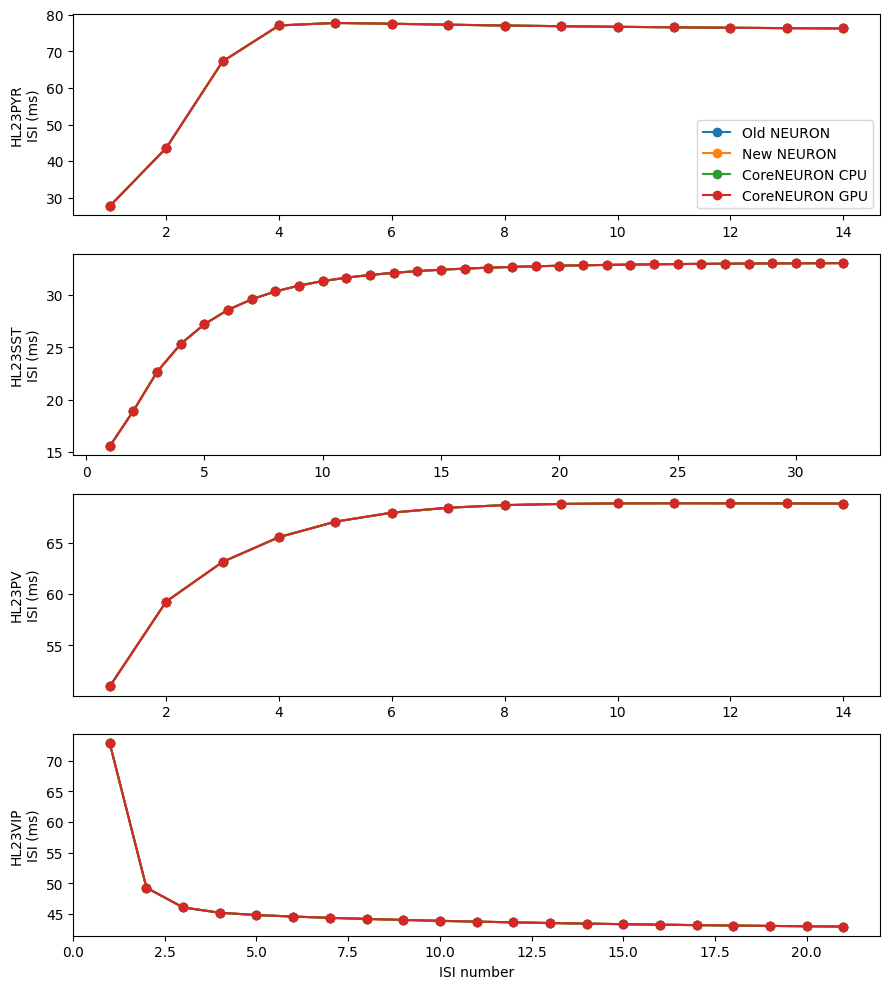

In [ ]:
fig, axes = plt.subplots(
    4,
    1,
    figsize=(9, 10),
    sharex=False
)

for ax, pop in zip(
    axes,
    populations
):

    for backend in single.keys():

        temp = isi_df[
            (isi_df['Population'] == pop) &
            (isi_df['Backend'] == backend)
        ]

        ax.plot(
            temp['ISI number'],
            temp['ISI (ms)'],
            marker='o',
            label=backend
        )

    ax.set_ylabel(
        f'{pop}\nISI (ms)'
    )

axes[0].legend()

axes[-1].set_xlabel(
    'ISI number'
)

plt.tight_layout()
plt.show()

In [ ]:
cases = [
    'Old NEURON',
    'New NEURON',
    'CoreNEURON CPU',
    'CoreNEURON GPU',
    'New mod NEURON8'
]

for pop in populations:

    gid = single_voltage_cells[pop]
    cell = f'cell_{gid}'

    v_old = np.asarray(
        single['Old NEURON']['data']['V_soma'][cell]
    )

    v_new = np.asarray(
        single['New NEURON']['data']['V_soma'][cell]
    )

    v_cpu = np.asarray(
        single['CoreNEURON CPU']['data']['V_soma'][cell]
    )

    v_gpu = np.asarray(
        single['CoreNEURON GPU']['data']['V_soma'][cell]
    )

    print('\n', pop)

    comparisons = {
        'New vs Old': v_new - v_old,
        'CN CPU vs Old': v_cpu - v_old,
        'CN GPU vs Old': v_gpu - v_old,

        'CN CPU vs New': v_cpu - v_new,
        'CN GPU vs New': v_gpu - v_new,
        'CN GPU vs CN CPU': v_gpu - v_cpu,
    }

    for name, dv in comparisons.items():

        print(
            f'{name:20s}',
            f'max|dV|={np.max(np.abs(dv)):.15g} mV',
            f'RMSE={np.sqrt(np.mean(dv**2)):.15g} mV'
        )


 HL23PYR
New vs Old           max|dV|=6.7378138624008e-09 mV RMSE=1.35708541669945e-10 mV
CN CPU vs Old        max|dV|=1.47294585417512e-08 mV RMSE=3.1184719510538e-10 mV
CN GPU vs Old        max|dV|=1.308301023073e-09 mV RMSE=2.58143900444918e-11 mV
CN CPU vs New        max|dV|=7.99164467935043e-09 mV RMSE=1.79352131671599e-10 mV
CN GPU vs New        max|dV|=5.81161962998067e-09 mV RMSE=1.3846846209169e-10 mV
CN GPU vs CN CPU     max|dV|=1.38032643093311e-08 mV RMSE=3.16523548970588e-10 mV

 HL23SST
New vs Old           max|dV|=2.69143818343309e-10 mV RMSE=1.28993822771961e-11 mV
CN CPU vs Old        max|dV|=3.76228825871294e-10 mV RMSE=2.32500261105359e-11 mV
CN GPU vs Old        max|dV|=4.66364724616142e-10 mV RMSE=2.38024220416679e-11 mV
CN CPU vs New        max|dV|=3.70932617954622e-10 mV RMSE=1.92113533983693e-11 mV
CN GPU vs New        max|dV|=3.34524408174275e-10 mV RMSE=1.90370844816945e-11 mV
CN GPU vs CN CPU     max|dV|=1.90951254808169e-10 mV RMSE=8.76568079829103e-12 mV



In [ ]:
single_spike_summary = []

for pop in populations:

    gid = single_voltage_cells[pop]
    cell = f'cell_{gid}'

    for backend, run in single.items():

        v = np.asarray(
            run['data']['V_soma'][cell]
        )

        spikes = get_spike_times_from_voltage(
            v,
            run['dt'],
            threshold=0.0
        )

        isi = np.diff(spikes)

        mean_isi = np.mean(isi)

        frequency = (
            1000.0 / mean_isi
            if len(isi) > 0
            else np.nan
        )

        single_spike_summary.append({
            'Population': pop,
            'Backend': backend,
            'N spikes': len(spikes),
            'Mean ISI (ms)': mean_isi,
            'Frequency (Hz)': frequency
        })

single_spike_summary = pd.DataFrame(
    single_spike_summary
)

single_spike_summary

,Population,Backend,N spikes,Mean ISI (ms),Frequency (Hz)
0,HL23PYR,Old NEURON,15,70.296931,14.225372
1,HL23PYR,CoreNEURON CPU,15,70.302714,14.224202
2,HL23PYR,CoreNEURON GPU,15,70.302714,14.224202
3,HL23SST,Old NEURON,33,30.620108,32.658278
4,HL23SST,CoreNEURON CPU,33,30.623463,32.654700
5,HL23SST,CoreNEURON GPU,33,30.623463,32.654700
6,HL23PV,Old NEURON,15,65.977719,15.156632
7,HL23PV,CoreNEURON CPU,15,65.975942,15.157040
8,HL23PV,CoreNEURON GPU,15,65.975942,15.157040
9,HL23VIP,Old NEURON,22,45.467517,21.993724


In [ ]:
for pop in populations:

    temp = single_spike_summary[
        single_spike_summary['Population'] == pop
    ]

    ref_freq = temp.loc[
        temp['Backend'] == 'Old NEURON',
        'Frequency (Hz)'
    ].iloc[0]

    print('\n', pop)

    for backend in [
        'CoreNEURON CPU',
        'CoreNEURON GPU'
    ]:

        freq = temp.loc[
            temp['Backend'] == backend,
            'Frequency (Hz)'
        ].iloc[0]

        diff = 100 * (
            freq - ref_freq
        ) / ref_freq

        print(
            backend,
            f'{freq:.6f} Hz',
            f'({diff:+.6f} %)'
        )


 HL23PYR
CoreNEURON CPU 14.224202 Hz (-0.008227 %)
CoreNEURON GPU 14.224202 Hz (-0.008227 %)

 HL23SST
CoreNEURON CPU 32.654700 Hz (-0.010955 %)
CoreNEURON GPU 32.654700 Hz (-0.010955 %)

 HL23PV
CoreNEURON CPU 15.157040 Hz (+0.002694 %)
CoreNEURON GPU 15.157040 Hz (+0.002694 %)

 HL23VIP
CoreNEURON CPU 21.991377 Hz (-0.010670 %)
CoreNEURON GPU 21.991377 Hz (-0.010670 %)


In [ ]:
for pop in populations:

    gid = single_voltage_cells[pop]
    cell = f'cell_{gid}'

    v_cpu = np.asarray(
        single['CoreNEURON CPU']
        ['data']['V_soma'][cell]
    )

    v_gpu = np.asarray(
        single['CoreNEURON GPU']
        ['data']['V_soma'][cell]
    )

    dv = v_gpu - v_cpu

    print(
        f'{pop:10s}',
        'CPU vs GPU:',
        f'max |ΔV| = {np.max(np.abs(dv)):.15g} mV',
        f'RMSE = {np.sqrt(np.mean(dv**2)):.15g} mV'
    )

HL23PYR    CPU vs GPU: max |ΔV| = 2.25260876618449e-09 mV RMSE = 6.48557096327577e-11 mV
HL23SST    CPU vs GPU: max |ΔV| = 3.47172957049224e-10 mV RMSE = 1.88831096792995e-11 mV
HL23PV     CPU vs GPU: max |ΔV| = 1.81944379562538e-08 mV RMSE = 2.6891834971438e-10 mV
HL23VIP    CPU vs GPU: max |ΔV| = 1.68465064120937e-09 mV RMSE = 9.04731805378189e-11 mV


In [ ]:
single_error_table = pd.DataFrame(
    single_error_rows
)

single_error_table

,Population,Backend,Max |dV| (mV),RMSE (mV),MAE (mV)
0,HL23PYR,CoreNEURON CPU,40.187762,1.001778,0.099123
1,HL23PYR,CoreNEURON GPU,40.187762,1.001778,0.099123
2,HL23SST,CoreNEURON CPU,22.909747,1.606973,0.314683
3,HL23SST,CoreNEURON GPU,22.909747,1.606973,0.314683
4,HL23PV,CoreNEURON CPU,16.919399,0.402544,0.039585
5,HL23PV,CoreNEURON GPU,16.919399,0.402544,0.039585
6,HL23VIP,CoreNEURON CPU,21.146650,1.221630,0.221402
7,HL23VIP,CoreNEURON GPU,21.146650,1.221630,0.221402


# Network

In [ ]:
analysis_start = 200.0
analysis_end = network['NEURON 1 Core']['duration']

print(
    'Analysis window:',
    analysis_start,
    '-',
    analysis_end,
    'ms'
)

def population_firing_rate(
    run,
    population,
    t_start=0.0,
    t_end=None
):

    if t_end is None:
        t_end = run['duration']

    gids = get_population_gids(
        run,
        population
    )

    mask = (
        (run['spkt'] >= t_start) &
        (run['spkt'] < t_end) &
        np.isin(run['spkid'], gids)
    )

    n_spikes = np.sum(mask)

    duration_s = (
        t_end - t_start
    ) / 1000.0

    return (
        n_spikes /
        len(gids) /
        duration_s
    )

def population_cv(
    run,
    population,
    t_start=0.0,
    t_end=None
):

    if t_end is None:
        t_end = run['duration']

    gids = get_population_gids(
        run,
        population
    )

    cell_cvs = []

    for gid in gids:

        spikes = run['spkt'][
            (run['spkid'] == gid) &
            (run['spkt'] >= t_start) &
            (run['spkt'] < t_end)
        ]

        # At least 3 spikes gives at least 2 ISIs
        if len(spikes) < 3:
            continue

        isi = np.diff(spikes)

        if np.mean(isi) > 0:

            cv = (
                np.std(isi) /
                np.mean(isi)
            )

            cell_cvs.append(cv)

    if len(cell_cvs) == 0:
        return np.nan

    return np.mean(cell_cvs)

def population_kuramoto(
    run,
    population,
    t_start=0.0,
    t_end=None,
    sample_dt=1.0,
    min_cells=2
):

    if t_end is None:
        t_end = run['duration']

    gids = get_population_gids(
        run,
        population
    )

    t = np.arange(
        t_start,
        t_end,
        sample_dt
    )

    phases = np.full(
        (len(gids), len(t)),
        np.nan
    )

    for i, gid in enumerate(gids):

        spikes = run['spkt'][
            run['spkid'] == gid
        ]

        if len(spikes) < 2:
            continue

        for k in range(
            len(spikes) - 1
        ):

            t0 = spikes[k]
            t1 = spikes[k + 1]

            mask = (
                (t >= t0) &
                (t < t1)
            )

            if not np.any(mask):
                continue

            phases[i, mask] = (
                2 * np.pi *
                (t[mask] - t0) /
                (t1 - t0)
            )

    R = np.full(
        len(t),
        np.nan
    )

    for j in range(len(t)):

        valid = np.isfinite(
            phases[:, j]
        )

        if np.sum(valid) >= min_cells:

            R[j] = np.abs(
                np.mean(
                    np.exp(
                        1j * phases[valid, j]
                    )
                )
            )

    return (
        t,
        R,
        np.nanmean(R)
    )

In [704]:
def population_cv(
    run,
    population,
    t_start=0.0,
    t_end=None
):

    if t_end is None:
        t_end = run['duration']

    gids = get_population_gids(
        run,
        population
    )

    cell_cvs = []

    for gid in gids:

        spikes = run['spkt'][
            (run['spkid'] == gid) &
            (run['spkt'] >= t_start) &
            (run['spkt'] < t_end)
        ]

        # At least 3 spikes gives at least 2 ISIs
        if len(spikes) < 3:
            continue

        isi = np.diff(spikes)

        if np.mean(isi) > 0:

            cv = (
                np.std(isi) /
                np.mean(isi)
            )

            cell_cvs.append(cv)

    if len(cell_cvs) == 0:
        return np.nan

    return np.mean(cell_cvs)

In [718]:
network_rows = []

for backend, run in network.items():

    for pop in populations:

        rate = population_firing_rate(
            run,
            pop,
            analysis_start,
            analysis_end
        )

        cv = population_cv(
            run,
            pop,
            analysis_start,
            analysis_end
        )

        _, _, kuramoto = population_kuramoto(
            run,
            pop,
            analysis_start,
            analysis_end,
            sample_dt=1.0
        )

        network_rows.append({
            'Backend': backend,
            'Population': pop,
            'Firing rate (Hz)': rate,
            'CV ISI': cv,
            'Kuramoto R': kuramoto,
        })

network_metrics = pd.DataFrame(
    network_rows
)

network_metrics

,Backend,Population,Firing rate (Hz),CV ISI,Kuramoto R
0,NEURON 1 Core,HL23PYR,9.327500,0.126489,0.224536
1,NEURON 1 Core,HL23SST,22.040000,0.472101,0.465437
2,NEURON 1 Core,HL23PV,3.542857,0.686270,0.448238
3,NEURON 1 Core,HL23VIP,10.175000,0.302923,0.380457
4,NEURON 2 Core,HL23PYR,9.297500,0.127735,0.242522
5,NEURON 2 Core,HL23SST,22.000000,0.470754,0.487024
6,NEURON 2 Core,HL23PV,3.857143,0.663113,0.456169
7,NEURON 2 Core,HL23VIP,10.250000,0.307706,0.436381
8,NEURON 10 Core,HL23PYR,9.335000,0.126022,0.224574
9,NEURON 10 Core,HL23SST,22.880000,0.457257,0.430585


In [719]:
network_metrics.pivot(
    index='Population',
    columns='Backend',
    values='Firing rate (Hz)'
)

Backend,CoreNEURON 1 Core,CoreNEURON 10 Core,CoreNEURON 2 Core,CoreNEURON 20 Core,CoreNEURON GPU,NEURON 1 Core,NEURON 10 Core,NEURON 2 Core,NEURON 20 Core
Population,,,,,,,,,
HL23PV,3.542857,3.342857,3.857143,3.514286,3.542857,3.542857,3.342857,3.857143,3.514286
HL23PYR,9.327500,9.335000,9.297500,9.292500,9.327500,9.327500,9.335000,9.297500,9.292500
HL23SST,22.040000,22.880000,22.000000,22.560000,22.040000,22.040000,22.880000,22.000000,22.560000
HL23VIP,10.175000,10.175000,10.250000,10.175000,10.175000,10.175000,10.175000,10.250000,10.175000


In [720]:
network_metrics.pivot(
    index='Population',
    columns='Backend',
    values='CV ISI'
)

Backend,CoreNEURON 1 Core,CoreNEURON 10 Core,CoreNEURON 2 Core,CoreNEURON 20 Core,CoreNEURON GPU,NEURON 1 Core,NEURON 10 Core,NEURON 2 Core,NEURON 20 Core
Population,,,,,,,,,
HL23PV,0.686270,0.781673,0.663113,0.719534,0.686270,0.686270,0.781673,0.663113,0.719534
HL23PYR,0.126489,0.126022,0.127735,0.125614,0.126489,0.126489,0.126022,0.127735,0.125614
HL23SST,0.472101,0.457257,0.470754,0.437448,0.472101,0.472101,0.457257,0.470754,0.437448
HL23VIP,0.302923,0.277694,0.307706,0.268213,0.302923,0.302923,0.277694,0.307706,0.268213


In [721]:
network_metrics.pivot(
    index='Population',
    columns='Backend',
    values='Kuramoto R'
)

Backend,CoreNEURON 1 Core,CoreNEURON 10 Core,CoreNEURON 2 Core,CoreNEURON 20 Core,CoreNEURON GPU,NEURON 1 Core,NEURON 10 Core,NEURON 2 Core,NEURON 20 Core
Population,,,,,,,,,
HL23PV,0.448238,0.369630,0.456169,0.395708,0.448238,0.448238,0.369630,0.456169,0.395708
HL23PYR,0.224536,0.224574,0.242522,0.241025,0.224536,0.224536,0.224574,0.242522,0.241025
HL23SST,0.465437,0.430585,0.487024,0.431810,0.465437,0.465437,0.430585,0.487024,0.431810
HL23VIP,0.380457,0.391263,0.436381,0.391400,0.380457,0.380457,0.391263,0.436381,0.391400


In [722]:
backends = [
    'NEURON 1 Core',
    'NEURON 2 Core',
    'NEURON 10 Core',
    'NEURON 20 Core',
    'CoreNEURON 1 Core',
    'CoreNEURON 2 Core',
    'CoreNEURON 10 Core',
    'CoreNEURON 20 Core',
    'CoreNEURON GPU'
]

for pop in populations:
    for backend in backends:

        temp = network_metrics[
            (network_metrics['Backend'] == backend) &
            (network_metrics['Population'] == pop)
        ]

        if temp.empty:
            print(
                "MISSING:",
                f"Population={pop}",
                f"Backend={backend}"
            )

In [724]:
print("Backends currently inside network_metrics:")

for x in network_metrics['Backend'].unique():
    print(repr(x))

print("\nPopulations:")

for x in network_metrics['Population'].unique():
    print(repr(x))

Backends currently inside network_metrics:
'NEURON 1 Core'
'NEURON 2 Core'
'NEURON 10 Core'
'NEURON 20 Core'
'CoreNEURON 1 Core'
'CoreNEURON 2 Core'
'CoreNEURON 10 Core'
'CoreNEURON 20 Core'
'CoreNEURON GPU'

Populations:
'HL23PYR'
'HL23SST'
'HL23PV'
'HL23VIP'


In [728]:
backends = [
    'NEURON 1 Core',
    'NEURON 2 Core',
    'NEURON 10 Core',
    'NEURON 20 Core',
    'CoreNEURON 1 Core',
    'CoreNEURON 2 Core',
    'CoreNEURON 10 Core',
    'CoreNEURON 20 Core',
    'CoreNEURON GPU'
]

comparison_rows = []

for pop in populations:

    ref_df = network_metrics[
        (network_metrics['Backend'] == 'NEURON 1 Core') &
        (network_metrics['Population'] == pop)
    ]

    assert len(ref_df) == 1, (
        f"Reference problem: pop={pop}, "
        f"found {len(ref_df)} rows"
    )

    ref = ref_df.iloc[0]

    for backend in backends:

        row_df = network_metrics[
            (network_metrics['Backend'] == backend) &
            (network_metrics['Population'] == pop)
        ]

        assert len(row_df) == 1, (
            f"Problem: backend={backend}, "
            f"pop={pop}, "
            f"found {len(row_df)} rows"
        )

        row = row_df.iloc[0]

        comparison_rows.append({

            'Population': pop,
            'Backend': backend,

            'Rate difference (Hz)':
                row['Firing rate (Hz)']
                - ref['Firing rate (Hz)'],

            'Rate difference (%)':
                100 *
                (
                    row['Firing rate (Hz)']
                    - ref['Firing rate (Hz)']
                )
                /
                ref['Firing rate (Hz)'],

            'CV difference':
                row['CV ISI']
                - ref['CV ISI'],

            'Kuramoto difference':
                row['Kuramoto R']
                - ref['Kuramoto R']
        })


network_differences = pd.DataFrame(
    comparison_rows
)

network_differences

,Population,Backend,Rate difference (Hz),Rate difference (%),CV difference,Kuramoto difference
0,HL23PYR,NEURON 1 Core,0.000000,0.000000,0.000000,0.000000
1,HL23PYR,NEURON 2 Core,-0.030000,-0.321630,0.001246,0.017986
2,HL23PYR,NEURON 10 Core,0.007500,0.080407,-0.000466,0.000038
3,HL23PYR,NEURON 20 Core,-0.035000,-0.375235,-0.000875,0.016489
4,HL23PYR,CoreNEURON 1 Core,0.000000,0.000000,0.000000,0.000000
5,HL23PYR,CoreNEURON 2 Core,-0.030000,-0.321630,0.001246,0.017986
6,HL23PYR,CoreNEURON 10 Core,0.007500,0.080407,-0.000466,0.000038
7,HL23PYR,CoreNEURON 20 Core,-0.035000,-0.375235,-0.000875,0.016489
8,HL23PYR,CoreNEURON GPU,0.000000,0.000000,0.000000,0.000000
9,HL23SST,NEURON 1 Core,0.000000,0.000000,0.000000,0.000000


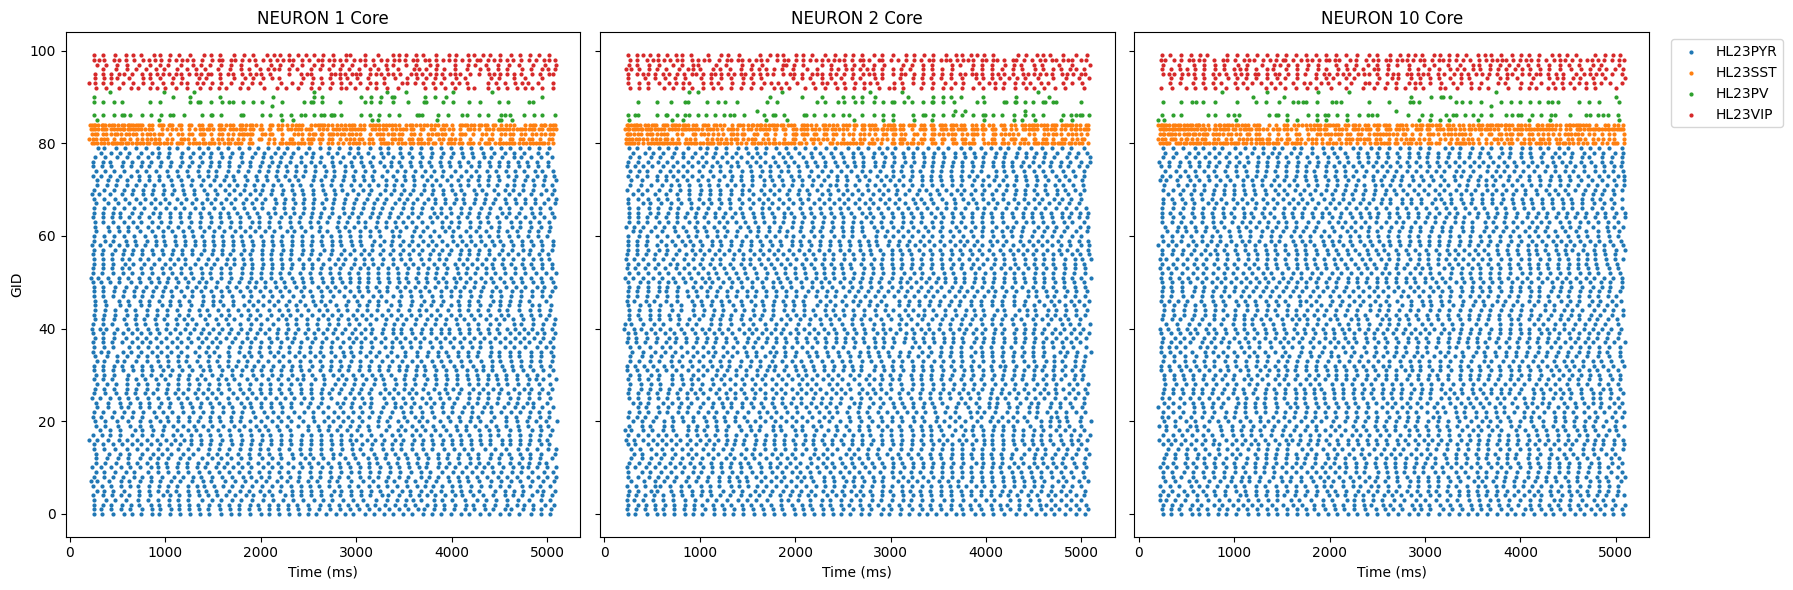

In [729]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    sharex=True,
    sharey=True
)

for ax, (backend, run) in zip(
    axes,
    network.items()
):

    for pop in populations:

        gids = get_population_gids(
            run,
            pop
        )

        mask = (
            (run['spkt'] >= analysis_start) &
            (run['spkt'] < analysis_end) &
            np.isin(run['spkid'], gids)
        )

        ax.scatter(
            run['spkt'][mask],
            run['spkid'][mask],
            s=4,
            label=pop
        )

    ax.set_title(backend)
    ax.set_xlabel('Time (ms)')

axes[0].set_ylabel('GID')

axes[-1].legend(
    bbox_to_anchor=(1.03, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [650]:
def population_psth(
    run,
    population,
    bin_size=10.0,
    t_start=0.0,
    t_end=None
):

    if t_end is None:
        t_end = run['duration']

    gids = get_population_gids(
        run,
        population
    )

    mask = (
        (run['spkt'] >= t_start) &
        (run['spkt'] < t_end) &
        np.isin(run['spkid'], gids)
    )

    spikes = run['spkt'][mask]

    bins = np.arange(
        t_start,
        t_end + bin_size,
        bin_size
    )

    counts, edges = np.histogram(
        spikes,
        bins=bins
    )

    centers = (
        edges[:-1] +
        edges[1:]
    ) / 2

    rate = (
        counts /
        len(gids) /
        (bin_size / 1000)
    )

    return centers, rate

In [651]:
def spike_count_per_gid(
    run,
    t_start=0.0,
    t_end=None
):

    if t_end is None:
        t_end = run['duration']

    gids = sorted(
        run['cellType'].keys()
    )

    counts = {}

    for gid in gids:

        counts[gid] = np.sum(
            (run['spkid'] == gid) &
            (run['spkt'] >= t_start) &
            (run['spkt'] < t_end)
        )

    return counts

In [730]:
spike_counts = {
    backend: spike_count_per_gid(
        run,
        analysis_start,
        analysis_end
    )
    for backend, run in network.items()
}

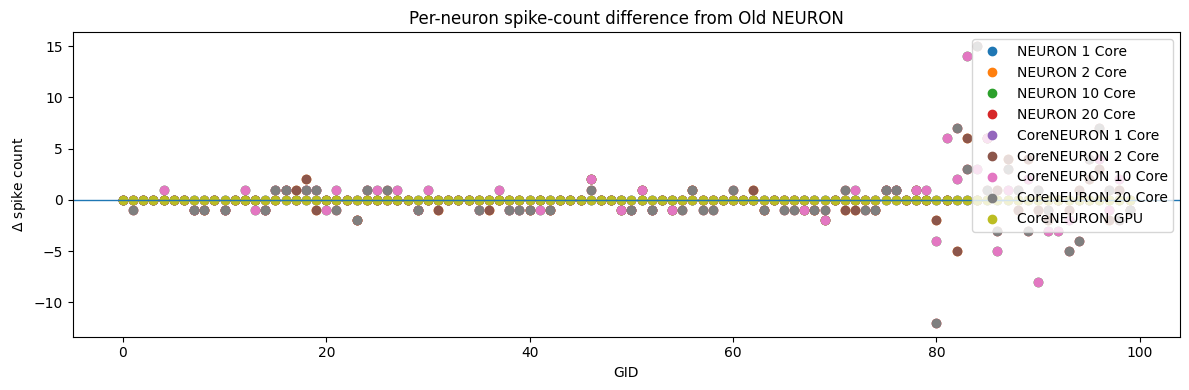

In [731]:
ref_counts = spike_counts[
    'NEURON 1 Core'
]

gids = np.array(
    sorted(ref_counts.keys())
)

fig, ax = plt.subplots(
    figsize=(12, 4)
)

for backend in [
    'NEURON 1 Core',
    'NEURON 2 Core',
    'NEURON 10 Core',
    'NEURON 20 Core',
    'CoreNEURON 1 Core',
    'CoreNEURON 2 Core',
    'CoreNEURON 10 Core',
    'CoreNEURON 20 Core',
    'CoreNEURON GPU'
]:

    diff = np.array([
        spike_counts[backend][gid]
        - ref_counts[gid]
        for gid in gids
    ])

    ax.plot(
        gids,
        diff,
        marker='o',
        linestyle='none',
        label=backend
    )

ax.axhline(
    0,
    linewidth=1
)

ax.set_xlabel('GID')
ax.set_ylabel(
    r'$\Delta$ spike count'
)

ax.set_title(
    'Per-neuron spike-count difference from Old NEURON'
)

ax.legend()

plt.tight_layout()
plt.show()

In [732]:
ref_array = np.array([
    ref_counts[gid]
    for gid in gids
])

for backend in [
    'NEURON 1 Core',
    'NEURON 2 Core',
    'NEURON 10 Core',
    'NEURON 20 Core',
    'CoreNEURON 1 Core',
    'CoreNEURON 2 Core',
    'CoreNEURON 10 Core',
    'CoreNEURON 20 Core',
    'CoreNEURON GPU'
]:

    backend_array = np.array([
        spike_counts[backend][gid]
        for gid in gids
    ])

    r = np.corrcoef(
        ref_array,
        backend_array
    )[0, 1]

    print(
        backend,
        'spike-count correlation =',
        r
    )

NEURON 1 Core spike-count correlation = 1.0
NEURON 2 Core spike-count correlation = 0.9966323118122052
NEURON 10 Core spike-count correlation = 0.9938791520153695
NEURON 20 Core spike-count correlation = 0.9907633734235066
CoreNEURON 1 Core spike-count correlation = 1.0
CoreNEURON 2 Core spike-count correlation = 0.9966323118122052
CoreNEURON 10 Core spike-count correlation = 0.9938791520153695
CoreNEURON 20 Core spike-count correlation = 0.9907633734235066
CoreNEURON GPU spike-count correlation = 1.0


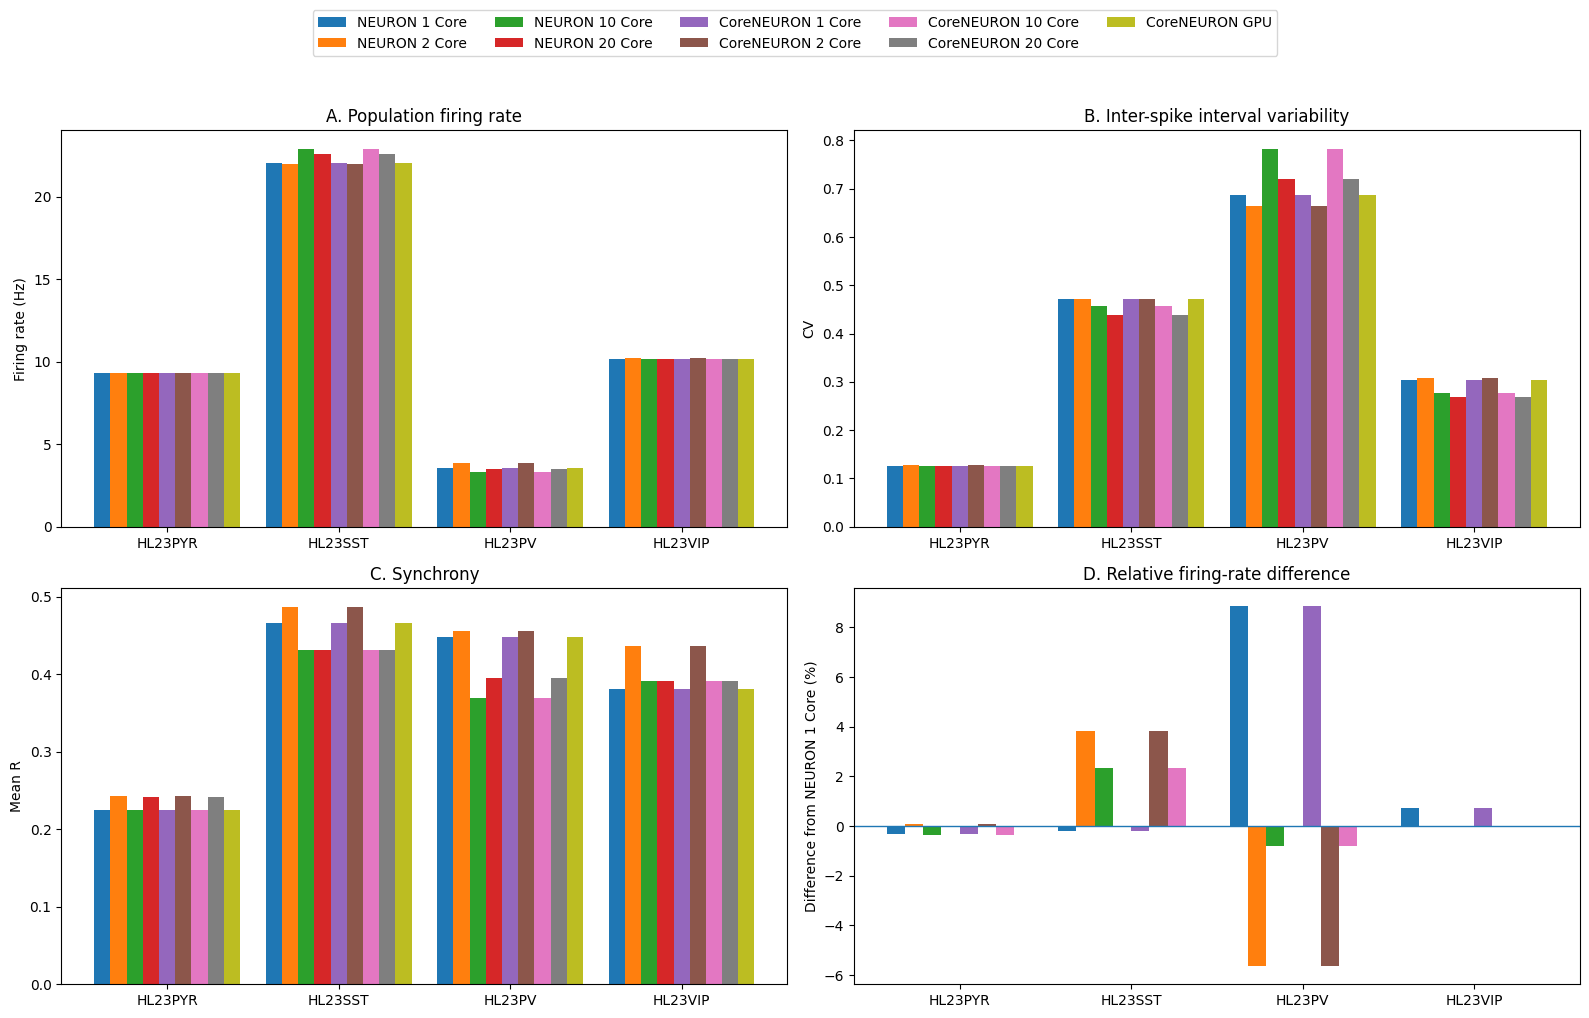

In [734]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

backends = [
    'NEURON 1 Core',
    'NEURON 2 Core',
    'NEURON 10 Core',
    'NEURON 20 Core',
    'CoreNEURON 1 Core',
    'CoreNEURON 2 Core',
    'CoreNEURON 10 Core',
    'CoreNEURON 20 Core',
    'CoreNEURON GPU'
]

populations = [
    'HL23PYR',
    'HL23SST',
    'HL23PV',
    'HL23VIP'
]

x = np.arange(len(populations))

# Total width occupied by each population group
group_width = 0.85

# Width of each individual bar
width = group_width / len(backends)

# Center all bars around x
offsets = (
    np.arange(len(backends))
    - (len(backends) - 1) / 2
) * width


fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)


# ============================================================
# Helper
# ============================================================

def get_metric_values(metric, backend):

    vals = []

    for pop in populations:

        temp = network_metrics.loc[
            (network_metrics['Backend'] == backend) &
            (network_metrics['Population'] == pop),
            metric
        ]

        if len(temp) != 1:
            raise ValueError(
                f'Expected one value for '
                f'{backend}, {pop}, {metric}; '
                f'found {len(temp)}'
            )

        vals.append(
            temp.iloc[0]
        )

    return vals


# ============================================================
# A. Firing rate
# ============================================================

ax = axes[0, 0]

for j, backend in enumerate(backends):

    vals = get_metric_values(
        'Firing rate (Hz)',
        backend
    )

    ax.bar(
        x + offsets[j],
        vals,
        width,
        label=backend
    )

ax.set_xticks(x)
ax.set_xticklabels(populations)

ax.set_ylabel(
    'Firing rate (Hz)'
)

ax.set_title(
    'A. Population firing rate'
)


# ============================================================
# B. CV
# ============================================================

ax = axes[0, 1]

for j, backend in enumerate(backends):

    vals = get_metric_values(
        'CV ISI',
        backend
    )

    ax.bar(
        x + offsets[j],
        vals,
        width
    )

ax.set_xticks(x)
ax.set_xticklabels(populations)

ax.set_ylabel('CV')

ax.set_title(
    'B. Inter-spike interval variability'
)


# ============================================================
# C. Kuramoto
# ============================================================

ax = axes[1, 0]

for j, backend in enumerate(backends):

    vals = get_metric_values(
        'Kuramoto R',
        backend
    )

    ax.bar(
        x + offsets[j],
        vals,
        width
    )

ax.set_xticks(x)
ax.set_xticklabels(populations)

ax.set_ylabel('Mean R')

ax.set_title(
    'C. Synchrony'
)


# ============================================================
# D. Relative firing-rate difference
# ============================================================

ax = axes[1, 1]

# Don't plot reference because it is always zero
comparison_backends = [
    'NEURON 2 Core',
    'NEURON 10 Core',
    'NEURON 20 Core',
    'CoreNEURON 1 Core',
    'CoreNEURON 2 Core',
    'CoreNEURON 10 Core',
    'CoreNEURON 20 Core',
    'CoreNEURON GPU'
]

width_d = (
    group_width
    / len(comparison_backends)
)

offsets_d = (
    np.arange(
        len(comparison_backends)
    )
    -
    (
        len(comparison_backends) - 1
    ) / 2
) * width_d


for j, backend in enumerate(
    comparison_backends
):

    vals = []

    for pop in populations:

        temp = network_differences.loc[
            (
                network_differences[
                    'Population'
                ] == pop
            )
            &
            (
                network_differences[
                    'Backend'
                ] == backend
            ),
            'Rate difference (%)'
        ]

        if len(temp) != 1:
            raise ValueError(
                f'Expected one difference for '
                f'{backend}, {pop}; '
                f'found {len(temp)}'
            )

        vals.append(
            temp.iloc[0]
        )

    ax.bar(
        x + offsets_d[j],
        vals,
        width_d,
        label=backend
    )


ax.axhline(
    0,
    linewidth=1
)

ax.set_xticks(x)
ax.set_xticklabels(populations)

ax.set_ylabel(
    'Difference from NEURON 1 Core (%)'
)

ax.set_title(
    'D. Relative firing-rate difference'
)


# ============================================================
# Shared legend
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=5
)

plt.tight_layout(
    rect=[0, 0, 1, 0.93]
)

plt.show()

# Full Network

In [735]:
# ============================================================
# Paths
# ============================================================

BASE_DIR = '../data'


network_runs = {
    'NEURON': 'Full_Neuron_20cores',
    'CoreNEURON CPUs': 'Full_CoreNeuron_20cores',
    'CoreNEURON GPU': 'Full_CoreNeuron_GPU'
}


network_voltage_cells = {
    'HL23PYR': 0,
    'HL23SST': 80,
    'HL23PV': 85,
    'HL23VIP': 92,
}

populations = [
    'HL23PYR',
    'HL23SST',
    'HL23PV',
    'HL23VIP'
]

In [742]:
def load_netpyne_run(run_name, base_dir=BASE_DIR):

    filename = os.path.join(
        base_dir,
        run_name,
        f'{run_name}_0_data.pkl'
    )

    with open(filename, 'rb') as file:
        info = pkl.load(file)

    data = info['simData'].copy()

    sim_config = info['simConfig']

    duration = float(sim_config['duration'])
    dt = float(sim_config['dt'])

    spkt = np.asarray(data['spkt'], dtype=float)
    spkid = np.asarray(data['spkid'], dtype=int)

    # --------------------------------------------------------
    # cellTypeByIndex can sometimes have str keys after saving
    # --------------------------------------------------------

    raw_cell_type = sim_config['cellTypeByIndex']

    cell_type = {
        int(gid): pop
        for gid, pop in raw_cell_type.items()
    }

    return {
        'name': run_name,
        'info': info,
        'data': data,
        'config': sim_config,
        'duration': duration,
        'dt': dt,
        'spkt': spkt,
        'spkid': spkid,
        'cellType': cell_type,
    }

network = {
    label: load_netpyne_run(run)
    for label, run in network_runs.items()
}

In [743]:
analysis_start = 200.0
analysis_end = network['NEURON']['duration']

print(
    'Analysis window:',
    analysis_start,
    '-',
    analysis_end,
    'ms'
)

def population_firing_rate(
    run,
    population,
    t_start=0.0,
    t_end=None
):

    if t_end is None:
        t_end = run['duration']

    gids = get_population_gids(
        run,
        population
    )

    mask = (
        (run['spkt'] >= t_start) &
        (run['spkt'] < t_end) &
        np.isin(run['spkid'], gids)
    )

    n_spikes = np.sum(mask)

    duration_s = (
        t_end - t_start
    ) / 1000.0

    return (
        n_spikes /
        len(gids) /
        duration_s
    )

def population_cv(
    run,
    population,
    t_start=0.0,
    t_end=None
):

    if t_end is None:
        t_end = run['duration']

    gids = get_population_gids(
        run,
        population
    )

    cell_cvs = []

    for gid in gids:

        spikes = run['spkt'][
            (run['spkid'] == gid) &
            (run['spkt'] >= t_start) &
            (run['spkt'] < t_end)
        ]

        # At least 3 spikes gives at least 2 ISIs
        if len(spikes) < 3:
            continue

        isi = np.diff(spikes)

        if np.mean(isi) > 0:

            cv = (
                np.std(isi) /
                np.mean(isi)
            )

            cell_cvs.append(cv)

    if len(cell_cvs) == 0:
        return np.nan

    return np.mean(cell_cvs)

def population_kuramoto(
    run,
    population,
    t_start=0.0,
    t_end=None,
    sample_dt=1.0,
    min_cells=2
):

    if t_end is None:
        t_end = run['duration']

    gids = get_population_gids(
        run,
        population
    )

    t = np.arange(
        t_start,
        t_end,
        sample_dt
    )

    phases = np.full(
        (len(gids), len(t)),
        np.nan
    )

    for i, gid in enumerate(gids):

        spikes = run['spkt'][
            run['spkid'] == gid
        ]

        if len(spikes) < 2:
            continue

        for k in range(
            len(spikes) - 1
        ):

            t0 = spikes[k]
            t1 = spikes[k + 1]

            mask = (
                (t >= t0) &
                (t < t1)
            )

            if not np.any(mask):
                continue

            phases[i, mask] = (
                2 * np.pi *
                (t[mask] - t0) /
                (t1 - t0)
            )

    R = np.full(
        len(t),
        np.nan
    )

    for j in range(len(t)):

        valid = np.isfinite(
            phases[:, j]
        )

        if np.sum(valid) >= min_cells:

            R[j] = np.abs(
                np.mean(
                    np.exp(
                        1j * phases[valid, j]
                    )
                )
            )

    return (
        t,
        R,
        np.nanmean(R)
    )

Analysis window: 200.0 - 5000.0 ms


In [744]:
network_rows = []

for backend, run in network.items():

    for pop in populations:

        rate = population_firing_rate(
            run,
            pop,
            analysis_start,
            analysis_end
        )

        cv = population_cv(
            run,
            pop,
            analysis_start,
            analysis_end
        )

        _, _, kuramoto = population_kuramoto(
            run,
            pop,
            analysis_start,
            analysis_end,
            sample_dt=1.0
        )

        network_rows.append({
            'Backend': backend,
            'Population': pop,
            'Firing rate (Hz)': rate,
            'CV ISI': cv,
            'Kuramoto R': kuramoto,
        })

network_metrics = pd.DataFrame(
    network_rows
)

network_metrics

,Backend,Population,Firing rate (Hz),CV ISI,Kuramoto R
0,NEURON,HL23PYR,3.320052,0.563450,0.086536
1,NEURON,HL23SST,37.733333,0.491664,0.304665
2,NEURON,HL23PV,30.119048,0.697398,0.331416
3,NEURON,HL23VIP,21.182292,0.321756,0.377370
4,CoreNEURON CPUs,HL23PYR,3.320052,0.563450,0.086536
5,CoreNEURON CPUs,HL23SST,37.733333,0.491664,0.304665
6,CoreNEURON CPUs,HL23PV,30.119048,0.697398,0.331416
7,CoreNEURON CPUs,HL23VIP,21.182292,0.321756,0.377370
8,CoreNEURON GPU,HL23PYR,3.368490,0.566434,0.095899
9,CoreNEURON GPU,HL23SST,37.875000,0.503752,0.331947


In [745]:
network_metrics.pivot(
    index='Population',
    columns='Backend',
    values='Firing rate (Hz)'
)

Backend,CoreNEURON CPUs,CoreNEURON GPU,NEURON
Population,,,
HL23PV,30.119048,30.130952,30.119048
HL23PYR,3.320052,3.368490,3.320052
HL23SST,37.733333,37.875000,37.733333
HL23VIP,21.182292,21.395833,21.182292


In [ ]:
backends = [
    'NEURON',
    'CoreNEURON CPUs',
    'CoreNEURON GPU'
]

comparison_rows = []

for pop in populations:

    ref_df = network_metrics[
        (network_metrics['Backend'] == 'NEURON') &
        (network_metrics['Population'] == pop)
    ]

    assert len(ref_df) == 1, (
        f"Reference problem: pop={pop}, "
        f"found {len(ref_df)} rows"
    )

    ref = ref_df.iloc[0]

    for backend in backends:

        row_df = network_metrics[
            (network_metrics['Backend'] == backend) &
            (network_metrics['Population'] == pop)
        ]

        assert len(row_df) == 1, (
            f"Problem: backend={backend}, "
            f"pop={pop}, "
            f"found {len(row_df)} rows"
        )

        row = row_df.iloc[0]

        comparison_rows.append({

            'Population': pop,
            'Backend': backend,

            'Rate difference (Hz)':
                row['Firing rate (Hz)']
                - ref['Firing rate (Hz)'],

            'Rate difference (%)':
                100 *
                (
                    row['Firing rate (Hz)']
                    - ref['Firing rate (Hz)']
                )
                /
                ref['Firing rate (Hz)'],

            'CV difference':
                row['CV ISI']
                - ref['CV ISI'],

            'Kuramoto difference':
                row['Kuramoto R']
                - ref['Kuramoto R']
        })


network_differences = pd.DataFrame(
    comparison_rows
)

network_differences

,Population,Backend,Rate difference (Hz),Rate difference (%),CV difference,Kuramoto difference
0,HL23PYR,CoreNEURON CPUs,0.000000,0.000000,0.000000,0.000000
1,HL23PYR,CoreNEURON GPU,0.048438,1.458938,0.002985,0.009363
2,HL23SST,CoreNEURON CPUs,0.000000,0.000000,0.000000,0.000000
3,HL23SST,CoreNEURON GPU,0.141667,0.375442,0.012087,0.027282
4,HL23PV,CoreNEURON CPUs,0.000000,0.000000,0.000000,0.000000
5,HL23PV,CoreNEURON GPU,0.011905,0.039526,0.001687,0.024243
6,HL23VIP,CoreNEURON CPUs,0.000000,0.000000,0.000000,0.000000
7,HL23VIP,CoreNEURON GPU,0.213542,1.008114,-0.000584,0.017445


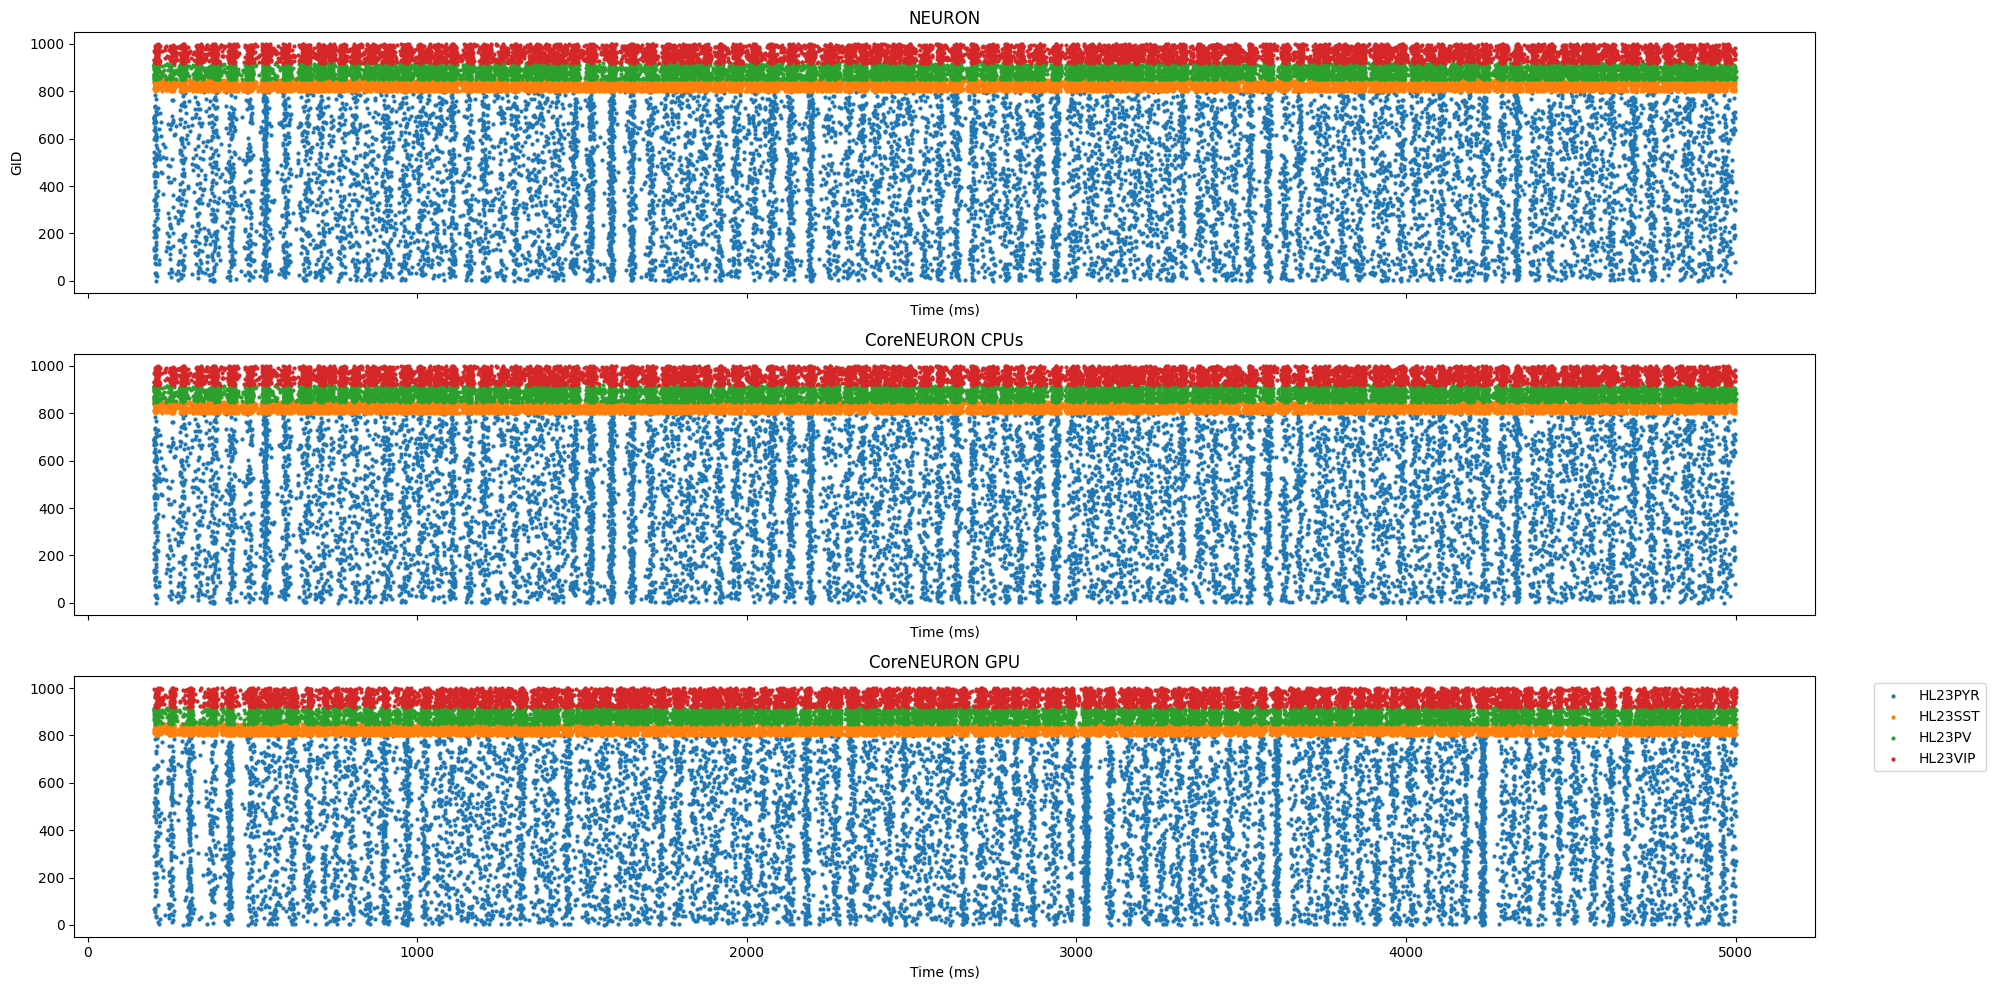

In [766]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(20, 10),
    sharex=True,
    sharey=True
)

for ax, (backend, run) in zip(
    axes,
    network.items()
):

    for pop in populations:

        gids = get_population_gids(
            run,
            pop
        )

        mask = (
            (run['spkt'] >= analysis_start) &
            (run['spkt'] < analysis_end) &
            np.isin(run['spkid'], gids)
        )

        ax.scatter(
            run['spkt'][mask],
            run['spkid'][mask],
            s=4,
            label=pop
        )

    ax.set_title(backend)
    ax.set_xlabel('Time (ms)')

axes[0].set_ylabel('GID')

axes[-1].legend(
    bbox_to_anchor=(1.03, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [771]:
import numpy as np
import pandas as pd


def raster_matrix(run, gids=None, bin_size=1.0, duration=None):
    """
    Convert NetPyNE spikes into a cell x time-bin spike-count matrix.

    Parameters
    ----------
    run : dict
        Your loaded simulation dictionary containing:
        run['spkt'], run['spkid'], run['duration']

    gids : array-like or None
        GIDs to include. If None, use all gids present.

    bin_size : float
        Time-bin width in ms.

    duration : float or None
        Simulation duration in ms.

    Returns
    -------
    matrix : ndarray
        Shape = (n_cells, n_bins)

    gids : ndarray
        GID ordering used in matrix.

    edges : ndarray
        Time-bin edges.
    """

    spkt = np.asarray(run['spkt'])
    spkid = np.asarray(run['spkid'])

    if duration is None:
        duration = run['duration']

    if gids is None:
        gids = np.unique(spkid)

    gids = np.asarray(gids)

    edges = np.arange(
        0,
        duration + bin_size,
        bin_size
    )

    matrix = np.zeros(
        (len(gids), len(edges) - 1),
        dtype=int
    )

    gid_to_row = {
        gid: i
        for i, gid in enumerate(gids)
    }

    for gid in gids:

        mask = spkid == gid

        counts, _ = np.histogram(
            spkt[mask],
            bins=edges
        )

        matrix[
            gid_to_row[gid], :
        ] = counts

    return matrix, gids, edges

def compare_rasters(
    run_ref,
    run_test,
    gids,
    bin_size=1.0
):

    duration = min(
        run_ref['duration'],
        run_test['duration']
    )

    A, gids_A, _ = raster_matrix(
        run_ref,
        gids=gids,
        bin_size=bin_size,
        duration=duration
    )

    B, gids_B, _ = raster_matrix(
        run_test,
        gids=gids,
        bin_size=bin_size,
        duration=duration
    )

    a = A.ravel()
    b = B.ravel()

    # Pearson correlation
    if np.std(a) == 0 or np.std(b) == 0:
        corr = np.nan
    else:
        corr = np.corrcoef(a, b)[0, 1]

    # Fraction of cell/time bins that are identical
    exact_fraction = np.mean(
        A == B
    )

    # Number of differing bins
    n_different = np.sum(
        A != B
    )

    # Total absolute spike-count difference
    absolute_difference = np.sum(
        np.abs(A - B)
    )

    return {
        'Correlation': corr,
        'Exact fraction': exact_fraction,
        'Different bins': n_different,
        'Absolute spike-count difference':
            absolute_difference
    }

raster_comparisons = []

reference = network['NEURON']

all_gids = sorted(
    reference['cellType'].keys()
)

for backend in [
    'CoreNEURON CPUs',
    'CoreNEURON GPU'
]:

    result = compare_rasters(
        reference,
        network[backend],
        gids=all_gids,
        bin_size=1.0
    )

    raster_comparisons.append({
        'Backend': backend,
        **result
    })

raster_comparisons = pd.DataFrame(
    raster_comparisons
)

raster_comparisons

,Backend,Correlation,Exact fraction,Different bins,Absolute spike-count difference
0,CoreNEURON CPUs,1.00000,1.000000,0,0
1,CoreNEURON GPU,0.04326,0.983919,80405,80405


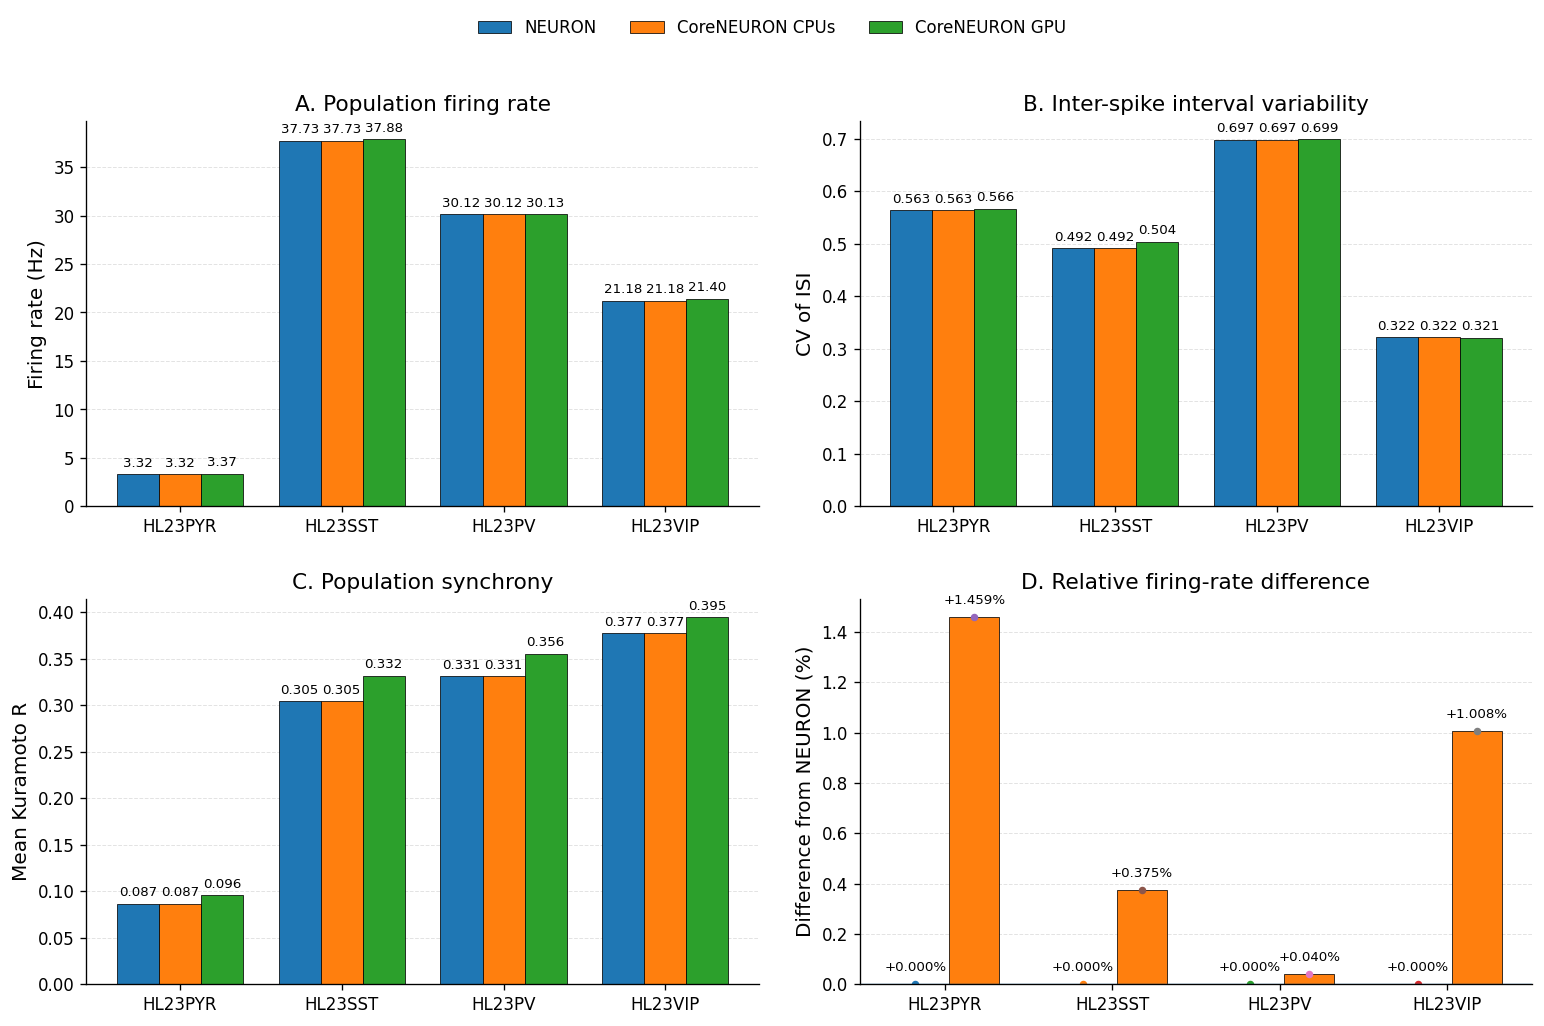

In [769]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Configuration
# ============================================================

backends = [
    'NEURON',
    'CoreNEURON CPUs',
    'CoreNEURON GPU'
]

populations = [
    'HL23PYR',
    'HL23SST',
    'HL23PV',
    'HL23VIP'
]

x = np.arange(len(populations))

group_width = 0.78
width = group_width / len(backends)

offsets = (
    np.arange(len(backends))
    - (len(backends) - 1) / 2
) * width


# ============================================================
# Plot style
# ============================================================

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120
})


fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8.5)
)


# ============================================================
# Helpers
# ============================================================

def get_metric_values(metric, backend):

    vals = []

    for pop in populations:

        temp = network_metrics.loc[
            (network_metrics['Backend'] == backend) &
            (network_metrics['Population'] == pop),
            metric
        ]

        if len(temp) != 1:
            raise ValueError(
                f'Expected one value for '
                f'{backend}, {pop}, {metric}; '
                f'found {len(temp)}'
            )

        vals.append(temp.iloc[0])

    return vals


def style_axis(ax):

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(
        axis='y',
        linestyle='--',
        linewidth=0.6,
        alpha=0.35
    )

    ax.set_axisbelow(True)


def annotate_bars(
    ax,
    bars,
    fmt='{:.2f}',
    fontsize=8,
    rotation=0
):

    ymax = ax.get_ylim()[1]
    offset = 0.012 * ymax

    for bar in bars:

        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + offset,
            fmt.format(value),
            ha='center',
            va='bottom',
            fontsize=fontsize,
            rotation=rotation
        )


# ============================================================
# A. Firing rate
# ============================================================

ax = axes[0, 0]

for j, backend in enumerate(backends):

    vals = get_metric_values(
        'Firing rate (Hz)',
        backend
    )

    bars = ax.bar(
        x + offsets[j],
        vals,
        width,
        label=backend,
        edgecolor='black',
        linewidth=0.45
    )

    annotate_bars(
        ax,
        bars,
        fmt='{:.2f}',
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(populations)

ax.set_ylabel('Firing rate (Hz)')
ax.set_title('A. Population firing rate')

style_axis(ax)


# ============================================================
# B. CV
# ============================================================

ax = axes[0, 1]

for j, backend in enumerate(backends):

    vals = get_metric_values(
        'CV ISI',
        backend
    )

    bars = ax.bar(
        x + offsets[j],
        vals,
        width,
        edgecolor='black',
        linewidth=0.45
    )

    annotate_bars(
        ax,
        bars,
        fmt='{:.3f}',
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(populations)

ax.set_ylabel('CV of ISI')
ax.set_title('B. Inter-spike interval variability')

style_axis(ax)


# ============================================================
# C. Kuramoto
# ============================================================

ax = axes[1, 0]

for j, backend in enumerate(backends):

    vals = get_metric_values(
        'Kuramoto R',
        backend
    )

    bars = ax.bar(
        x + offsets[j],
        vals,
        width,
        edgecolor='black',
        linewidth=0.45
    )

    annotate_bars(
        ax,
        bars,
        fmt='{:.3f}',
        fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(populations)

ax.set_ylabel('Mean Kuramoto R')
ax.set_title('C. Population synchrony')

style_axis(ax)


# ============================================================
# D. Relative firing-rate difference
# ============================================================

ax = axes[1, 1]

comparison_backends = [
    'CoreNEURON CPUs',
    'CoreNEURON GPU'
]

width_d = 0.30

offsets_d = np.array([
    -width_d / 1.7,
     width_d / 1.7
])

all_diff_values = []

for j, backend in enumerate(comparison_backends):

    vals = []

    for pop in populations:

        temp = network_differences.loc[
            (network_differences['Population'] == pop) &
            (network_differences['Backend'] == backend),
            'Rate difference (%)'
        ]

        if len(temp) != 1:
            raise ValueError(
                f'Expected one difference for '
                f'{backend}, {pop}; '
                f'found {len(temp)}'
            )

        vals.append(temp.iloc[0])

    all_diff_values.extend(vals)

    bars = ax.bar(
        x + offsets_d[j],
        vals,
        width_d,
        label=backend,
        edgecolor='black',
        linewidth=0.45
    )

    for bar, val in zip(bars, vals):

        xpos = (
            bar.get_x()
            + bar.get_width() / 2
        )

        # Make exact-zero values visible
        ax.plot(
            xpos,
            val,
            marker='o',
            markersize=3.5
        )

        ax.annotate(
            f'{val:+.3f}%',
            xy=(xpos, val),
            xytext=(
                0,
                6 if val >= 0 else -7
            ),
            textcoords='offset points',
            ha='center',
            va=(
                'bottom'
                if val >= 0
                else 'top'
            ),
            fontsize=8
        )


ax.axhline(
    0,
    linewidth=0.8
)

ax.set_xticks(x)
ax.set_xticklabels(populations)

ax.set_ylabel(
    'Difference from NEURON (%)'
)

ax.set_title(
    'D. Relative firing-rate difference'
)

style_axis(ax)


# ============================================================
# Shared legend
# ============================================================

handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False
)


plt.tight_layout(
    rect=[0, 0, 1, 0.94],
    h_pad=2.0,
    w_pad=2.0
)

plt.show()

# NEURON LFP

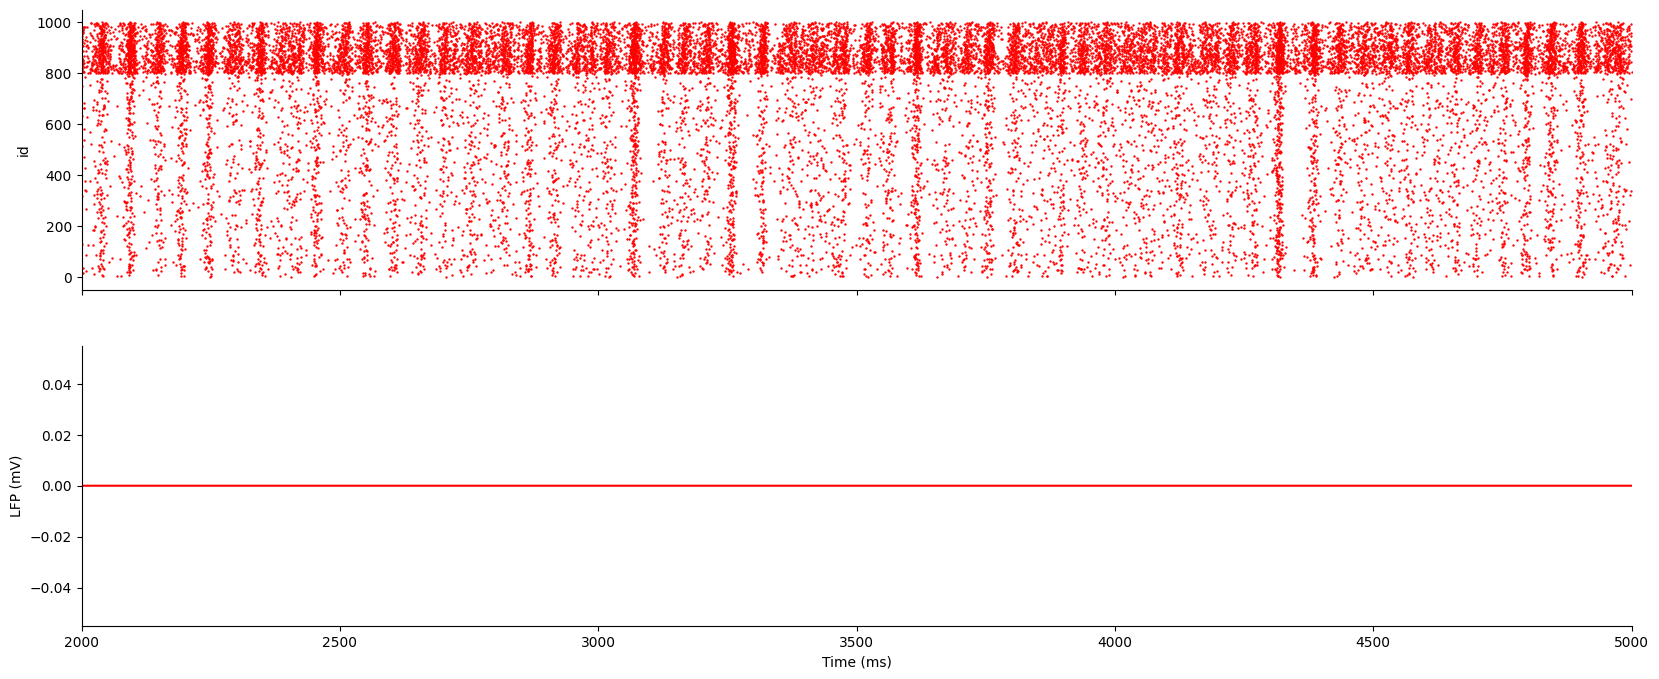

In [ ]:
with open('../data/Full_CoreNeuron_LFP_GPU/Full_CoreNeuron_LFP_GPU_0_data.pkl', 'rb') as file:
    info = pkl.load(file)

data = info['simData'].copy()
info.pop('simData', None)
cellType = info['simConfig']['cellTypeByIndex']
spkt = np.array(data['spkt'])
spkid = np.array(data['spkid'])
lfp = data['LFP']
lfp = np.array(lfp)
lfp = lfp[:,0]
time = np.linspace(0, info['simConfig']['duration'], int(info['simConfig']['duration']/info['simConfig']['dt']))
fs = 1/(info['simConfig']['dt']/1000) #Hz

filter=[1,200.0]
lfp_core = lfp#butter_bandpass_filter(lfp, filter[0], filter[1], fs, order=2)
#lfp_new = lfp_new[::20]
time_core = np.linspace(0,5000,len(lfp_core))

#time_lfp = np.linspace(0,5000,len(lfp))

pyr = [0,799]
sst = [800, 849]
pv = [850, 919]
vip = [920, 999]


fig, axes = plt.subplots(2,1,figsize=(20,8), sharex=True)

axes[0].scatter(spkt, spkid, s= 0.5, c='red')
axes[0].set_ylabel('id')

axes[1].plot(time_core, lfp_core, c='red')
axes[1].set_xlim(2000,5000)
axes[1].set_ylim(0.022,0.028)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('LFP (mV)')

sns.despine()

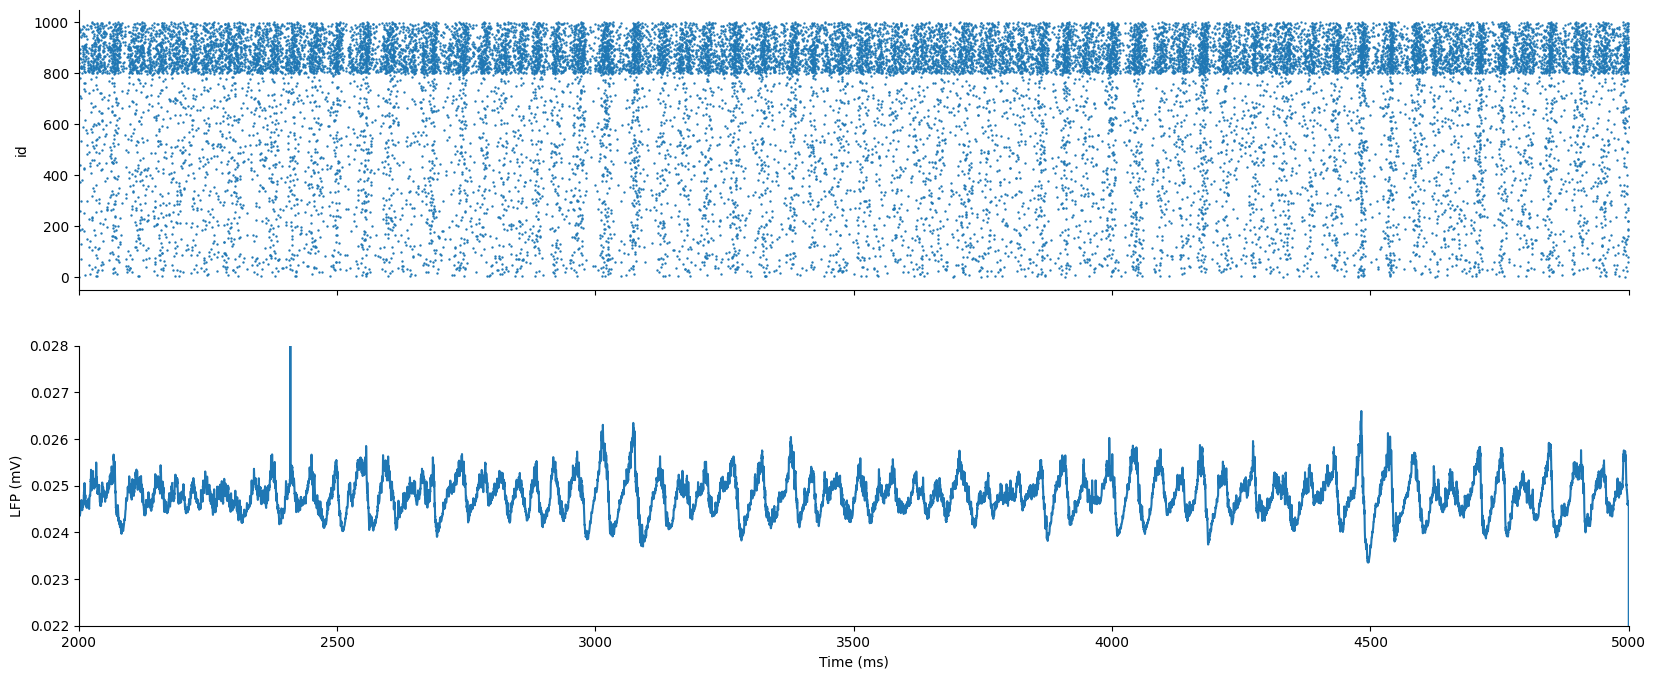

In [47]:
with open('../data/Full_Neuron_LFP/Full_Neuron_LFP_0_data.pkl', 'rb') as file:
    info = pkl.load(file)

data = info['simData'].copy()
info.pop('simData', None)
cellType = info['simConfig']['cellTypeByIndex']
spkt = np.array(data['spkt'])
spkid = np.array(data['spkid'])
lfp = data['LFP']
lfp = np.array(lfp)
lfp = lfp[:,0]
time = np.linspace(0, info['simConfig']['duration'], int(info['simConfig']['duration']/info['simConfig']['dt']))
fs = 1/(info['simConfig']['dt']/1000) #Hz

filter=[1,200.0]
lfp_new = lfp#butter_bandpass_filter(lfp, filter[0], filter[1], fs, order=2)
#lfp_new = lfp_new[::20]
time_lfp = np.linspace(0,5000,len(lfp_new))

#time_lfp = np.linspace(0,5000,len(lfp))

pyr = [0,799]
sst = [800, 849]
pv = [850, 919]
vip = [920, 999]


fig, axes = plt.subplots(2,1,figsize=(20,8), sharex=True)

axes[0].scatter(spkt, spkid, s= 0.5)
axes[0].set_ylabel('id')

axes[1].plot(time_lfp, lfp_new)
axes[1].set_xlim(2000,5000)
axes[1].set_ylim(0.022,0.028)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('LFP (mV)')

sns.despine()

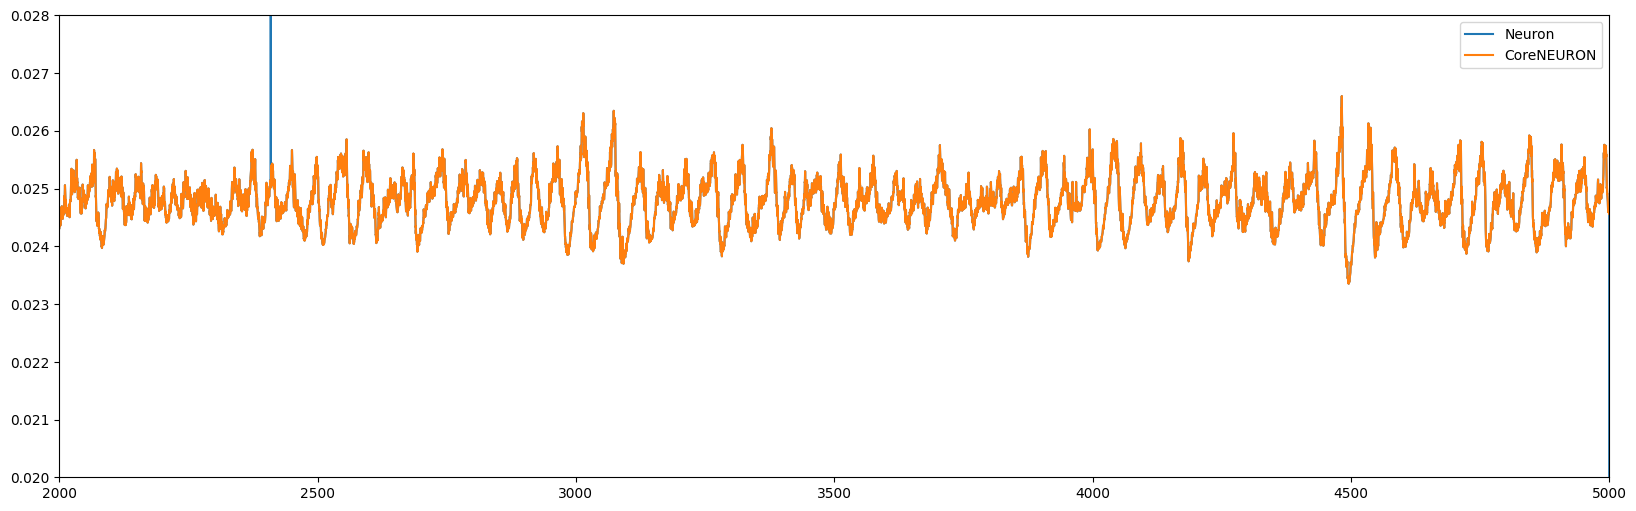

In [53]:
plt.figure(figsize=(20,6))
plt.plot(time_lfp, lfp_new, label='Neuron')
plt.plot(time_core, lfp_core, label='CoreNEURON')
plt.xlim(2000,5000)
plt.ylim(0.02,0.028)
plt.legend()